# Graph Import

In [ ]:
import networkx as nx
import os

# Raw string avoids issues with backslashes
os.chdir(r"C:\Nina\Studium Master\Porto\Network Science\Final Project")

# Step 1: Create a bipartite, undirected graph
G = nx.Graph()

# Define the ranges for each side of the bipartite graph
MAX_LEFT_NODES = 2146057   # users (left side)
MAX_RIGHT_NODES = 1230915  # products (right side)

with open("out.amazon-ratings", "r") as f:
    for line in f:
        if line.startswith('%'):
            continue
        parts = line.strip().split()
        if len(parts) >= 4:
            left_node = int(parts[0])   # user ID (1 to 2,146,057)
            right_node = int(parts[1])  # product ID (1 to 1,230,915)
            weight = float(parts[2])
            timestamp = int(parts[3])
            
            # Create distinct node IDs by offsetting the right side
            # Left side: 1 to 2,146,057 (users)
            # Right side: 2,146,058 to 2,146,057 + 1,230,915 (products)
            user_id = left_node
            product_id = right_node + MAX_LEFT_NODES
            
            G.add_edge(user_id, product_id, weight=weight, timestamp=timestamp)

# Set bipartite node attributes
# Left side (users): bipartite = 0
# Right side (products): bipartite = 1
user_nodes = range(1, MAX_LEFT_NODES + 1)
product_nodes = range(MAX_LEFT_NODES + 1, MAX_LEFT_NODES + MAX_RIGHT_NODES + 1)

nx.set_node_attributes(G, {node: 0 for node in user_nodes if node in G.nodes()}, 'bipartite')
nx.set_node_attributes(G, {node: 1 for node in product_nodes if node in G.nodes()}, 'bipartite')

# Get the two sets of nodes using the bipartite attributes we set
users = {n for n, d in G.nodes(data=True) if d.get('bipartite') == 0}
products = {n for n, d in G.nodes(data=True) if d.get('bipartite') == 1}

In [ ]:
import pickle

# Save graph to a file
with open('saved_graph_original.pickle', 'wb') as f:
    pickle.dump({
        'G_original': G
    }, f)

print("Graph saved")

Graph saved


In [ ]:
print(f"Users: {len(users)} nodes")
print(f"Products: {len(products)} nodes")

# Check for disconnected components
num_components = nx.number_connected_components(G)
print(f"Number of connected components: {num_components}")

if num_components > 1:
    largest_cc = max(nx.connected_components(G), key=len)
    print(f"Largest connected component has {len(largest_cc)} nodes")

print("First 5 edges with data:")
for u, v, data in list(G.edges(data=True))[:5]:
    print(u, v, data)

Graph has 3376972 nodes and 5743258 edges
Is bipartite: True
Users: 2146057 nodes
Products: 1230915 nodes
Number of connected components: 198291
Largest connected component has 2892456 nodes
First 5 edges with data:
1 2146058 {'weight': 5.0, 'timestamp': 1117404000}
1 2146059 {'weight': 1.0, 'timestamp': 1105916400}
1 2146060 {'weight': 5.0, 'timestamp': 1105916400}
1 2146061 {'weight': 1.0, 'timestamp': 1105570800}
1 2146062 {'weight': 1.0, 'timestamp': 1104966000}


# Train-Test-Split and Sampling

In [ ]:
import numpy as np
import networkx as nx
import datetime
from collections import defaultdict

# Step 1: Analyze and sort all edges by timestamp
edges = sorted(G.edges(data=True), key=lambda x: x[2]['timestamp'])
timestamps = [data['timestamp'] for _, _, data in edges]
min_timestamp = min(timestamps)
max_timestamp = max(timestamps)
timeframe = max_timestamp - min_timestamp
split_idx = int(0.7 * len(edges))  # Index for 70/30 split
split_timestamp = edges[split_idx][2]['timestamp']  # Exact timestamp at split point

print(f"Timestamp range: {min_timestamp} to {max_timestamp}")
print(f"Timeframe duration: {timeframe} seconds")
print(f"Split timestamp (70/30): {split_timestamp}")
print(f"Min date: {datetime.datetime.fromtimestamp(min_timestamp)}")
print(f"Max date: {datetime.datetime.fromtimestamp(max_timestamp)}")
print(f"Split date: {datetime.datetime.fromtimestamp(split_timestamp)}")

# Step 2: Create training and test graphs
G_train = nx.Graph()
G_test = nx.Graph()

# Add all nodes to both graphs first (preserve full node set)
G_train.add_nodes_from(G.nodes(data=True))
G_test.add_nodes_from(G.nodes(data=True))

# Split edges - now guaranteed exact 70/30 split
train_edges = edges[:split_idx]
test_edges = edges[split_idx:]

for u, v, data in train_edges:
    G_train.add_edge(u, v, **data)
    
for u, v, data in test_edges:
    G_test.add_edge(u, v, **data)

# Verification
print(f"\nTraining graph: {G_train.number_of_nodes()} nodes, {len(train_edges)} edges")
print(f"Test graph: {G_test.number_of_nodes()} nodes, {len(test_edges)} edges")
print(f"Total edges: {len(train_edges) + len(test_edges)} (original: {G.number_of_edges()})")
print(f"Test set %: {len(test_edges)/G.number_of_edges():.1%}")

# Save graphs
import pickle
with open('time_split_graphs.pickle', 'wb') as f:
    pickle.dump({
        'G_train': G_train,
        'G_test': G_test,
        'split_timestamp': split_timestamp,
        'edge_counts': (len(train_edges), len(test_edges))
    }, f)
print("Graphs saved to 'time_split_graphs.pickle'")

Timestamp range: 833493600 to 1148853600
Timeframe duration: 315360000 seconds
Split timestamp (70/30): 1106348400
Min date: 1996-05-31 00:00:00
Max date: 2006-05-29 00:00:00
Split date: 2005-01-22 00:00:00

Training graph: 3376972 nodes, 4020280 edges
Test graph: 3376972 nodes, 1722978 edges
Total edges: 5743258 (original: 5743258)
Test set %: 30.0%
Graphs saved to 'time_split_graphs.pickle'


In [4]:
import random
import pandas as pd
from collections import defaultdict

users = {n for n, d in G.nodes(data=True) if d.get('bipartite') == 0}
products = {n for n, d in G.nodes(data=True) if d.get('bipartite') == 1}

def sample_pairs_with_min_edges(G_train, G_test, users, products, n_samples=500, min_edges=3):
    """
    Samples balanced positive/negative pairs from bipartite graphs, requiring nodes to have
    at least min_edges connections in G_train.
    
    Returns:
        train_df, test_df: DataFrames with columns ['node1', 'node2', 'weight', 'label']
    """
    # Step 1: Identify active nodes with ≥ min_edges in G_train
    user_degrees = defaultdict(int)
    product_degrees = defaultdict(int)
    
    for u, v in G_train.edges():
        if u in users and v in products:
            user_degrees[u] += 1
            product_degrees[v] += 1
        elif v in users and u in products:
            user_degrees[v] += 1
            product_degrees[u] += 1
    
    active_users = {u for u in users if user_degrees[u] >= min_edges}
    active_products = {v for v in products if product_degrees[v] >= min_edges}
    
    print(f"Active users: {len(active_users)}, Active products: {len(active_products)}")

    # Step 2: Sample positive and negative pairs for training set
    def sample_for_graph(graph, active_users, active_products, n_samples):
        # Get all valid positive edges
        positive_candidates = [
            (u, v, data.get('weight', 1.0))
            for u, v, data in graph.edges(data=True)
            if u in active_users and v in active_products
        ]
        
        # Sample positive pairs
        positive_sample = random.sample(positive_candidates, min(n_samples, len(positive_candidates)))
        
        # Generate negative pairs
        negative_sample = []
        active_users_list = list(active_users)
        active_products_list = list(active_products)
        
        while len(negative_sample) < len(positive_sample):
            u = random.choice(active_users_list)
            v = random.choice(active_products_list)
            
            # Check if edge doesn't exist in original graph G
            if not G.has_edge(u, v):
                negative_sample.append((u, v, 0.0))  # weight=0 for negative pairs
        
        return positive_sample, negative_sample

    # Step 3: Sample for both train and test sets
    train_pos, train_neg = sample_for_graph(G_train, active_users, active_products, n_samples)
    test_pos, test_neg = sample_for_graph(G_test, active_users, active_products, n_samples)

    # Step 4: Create DataFrames
    def create_df(pos_pairs, neg_pairs):
        # Label positive pairs as 1, negative as 0
        pos_data = [(*pair, 1) for pair in pos_pairs]
        neg_data = [(*pair, 0) for pair in neg_pairs]
        
        df = pd.DataFrame(pos_data + neg_data, 
                         columns=['node1', 'node2', 'weight', 'label'])
        return df.sample(frac=1).reset_index(drop=True)  # Shuffle
    
    train_df = create_df(train_pos, train_neg)
    test_df = create_df(test_pos, test_neg)

    return train_df, test_df

In [ ]:
# Usage
train_df, test_df = sample_pairs_with_min_edges(
    G_train=G_train,
    G_test=G_test,
    users=users,
    products=products,
    n_samples=500,
    min_edges=3
)

print(f"Training samples: {len(train_df)} (Pos: {train_df['label'].sum()}, Neg: {len(train_df) - train_df['label'].sum()})")
print(f"Test samples: {len(test_df)} (Pos: {test_df['label'].sum()}, Neg: {len(test_df) - test_df['label'].sum()})")

Active users: 236947, Active products: 295726
Training samples: 1000 (Pos: 500, Neg: 500)
Test samples: 1000 (Pos: 500, Neg: 500)


In [ ]:
user_degrees = dict(G_train.degree(users))
product_degrees = dict(G_train.degree(products))
violating_user_nodes = test_df[
    (train_df['node1'].isin(users)) &
    (train_df['node1'].map(user_degrees.get, na_action='ignore') < 3)
]

violating_product_nodes = train_df[
    (train_df['node2'].isin(products)) &
    (train_df['node2'].map(product_degrees.get, na_action='ignore') < 3)
]
print(f"User nodes with degree < 3: {len(violating_user_nodes)}")
print(f"Product nodes with degree < 3: {len(violating_product_nodes)}")

User nodes with degree < 3: 0
Product nodes with degree < 3: 0


In [70]:
train_df.to_csv("train_df_min3.csv")
train_df.to_csv("train_df_min3.csv")

# Safety Checks

In [60]:
# Check if products are correctly tagged
print("Sample product nodes:", list(products)[:5])  # Should show nodes you expect to be products
print("Bipartite tags for these products:")
for node in list(products)[:5]:
    print(G.nodes[node])  # Should show {'bipartite': 1}

Sample product nodes: [2146058, 2146059, 2146060, 2146061, 2146062]
Bipartite tags for these products:
{'bipartite': 1}
{'bipartite': 1}
{'bipartite': 1}
{'bipartite': 1}
{'bipartite': 1}


In [61]:
# Count edges between users and products in G_train
user_product_edges = [
    (u, v) for u, v in G_train.edges() 
    if u in users and v in products
]
print(f"User-product edges in G_train: {len(user_product_edges)}")

User-product edges in G_train: 855244


In [62]:
# Check degrees of the first few products in G_train
for product in list(products)[:5]:
    degree = G_train.degree(product)
    print(f"Product {product} has degree {degree} in G_train")

Product 2146058 has degree 0 in G_train
Product 2146059 has degree 549 in G_train
Product 2146060 has degree 14 in G_train
Product 2146061 has degree 205 in G_train
Product 2146062 has degree 1143 in G_train


In [63]:
num_edges = G_train.number_of_edges()
print(f"Total edges in G_train: {num_edges}")

Total edges in G_train: 4020280


In [ ]:
# Count edges by type
user_user = [(u, v) for u, v in G_train.edges() if u in users and v in users]
product_product = [(u, v) for u, v in G_train.edges() if u in products and v in products]
user_product = [(u, v) for u, v in G_train.edges() if u in users and v in products]
product_user = [(u, v) for u, v in G_train.edges() if u in products and v in users]

print(f"User-User edges: {len(user_user)}")
print(f"Product-Product edges: {len(product_product)}")
print(f"User-Product edges: {len(user_product)}")
print(f"Product-User edges: {len(product_user)}") # shows that we need to be careful to consider u-v and v-u edges

User-User edges: 0
Product-Product edges: 0
User-Product edges: 855244
Product-User edges: 3165036


In [65]:
# Nodes in edges but missing from users/products sets
edge_nodes = set()
for u, v in G_train.edges():
    edge_nodes.update([u, v])

missing_users = edge_nodes - users - products
print("Nodes not in users/products sets:", missing_users)

Nodes not in users/products sets: set()


# Feature Calculation

In [5]:
# Unweighted methods

import numpy as np

# Preferential Attachment (unweighted)
def PA(G, x, y):
    return G.degree(x) * G.degree(y)

# Local Paths (length 3 only)
def count_paths_length_3(G, x, y):
    count = 0
    for path in nx.all_simple_paths(G, source=x, target=y, cutoff=3):
        if len(path) == 4:
            count += 1
    return count

# L3: unweighted, degree-normalized paths of length 3
def L3_unweighted(G, x, y):
    score = 0.0
    for path in nx.all_simple_paths(G, source=x, target=y, cutoff=3):
        if len(path) == 4:
            u, v = path[1], path[2]
            deg_u = G.degree(u)
            deg_v = G.degree(v)
            if deg_u > 0 and deg_v > 0:
                score += 1 / (deg_u * deg_v)**0.5
    return score

def compute_unweighted_shortest_path_lengths(df, G):
    lengths = []
    for u, v in zip(df['node1'], df['node2']):
        try:
            length = nx.shortest_path_length(G, source=u, target=v)
        except nx.NetworkXNoPath:
            length = None 
        lengths.append(length)
    return lengths

In [6]:
# Weighted Methods

def weighted_LP_length_3(G, x, y):
    total = 0.0
    for path in nx.all_simple_paths(G, source=x, target=y, cutoff=3):
        if len(path) == 4:
            # Get edge weights along the path
            weight_product = 1.0
            for i in range(3):
                edge_data = G.get_edge_data(path[i], path[i+1], default={})
                weight = edge_data.get('weight', 1.0)
                weight_product *= weight
            total += weight_product
    return total

def L3_weighted(G, x, y):
    score = 0.0
    for path in nx.all_simple_paths(G, source=x, target=y, cutoff=3):
        if len(path) == 4:
            u, v = path[1], path[2]
            # Get weights
            try:
                w1 = G.get_edge_data(path[0], u).get('weight', 1.0)
                w2 = G.get_edge_data(u, v).get('weight', 1.0)
                w3 = G.get_edge_data(v, path[3]).get('weight', 1.0)
            except AttributeError:
                w1 = w2 = w3 = 1.0

            deg_u = G.degree(u, weight='weight')
            deg_v = G.degree(v, weight='weight')
            if deg_u > 0 and deg_v > 0:
                score += (w1 * w2 * w3) / (deg_u * deg_v)**0.5
    return score

def PA_w(G, x, y):
    sum_x = sum(G[x][n]['weight'] for n in G.neighbors(x))
    sum_y = sum(G[y][n]['weight'] for n in G.neighbors(y))
    return sum_x * sum_y

def compute_weighted_shortest_path_lengths(df, G):
    lengths = []
    for u, v in zip(df['node1'], df['node2']):
        try:
            length = nx.shortest_path_length(
                G, source=u, target=v,
                weight=lambda u, v, d: 1 / d['weight'] if d['weight'] != 0 else float('inf')
            )
        except nx.NetworkXNoPath:
            length = None  
        lengths.append(length)
    return lengths

In [ ]:
import pickle

# Load the dictionary from the pickle file
with open('time_split_graphs.pickle', 'rb') as f:
    data = pickle.load(f)

# Access G_train
G_train = data['G_train']

train_df['PA'] = train_df.apply(lambda row: PA(G_train, row['node1'], row['node2']), axis=1)
train_df['PA'] = PA(train_df, G_train)
train_df.to_csv("train_df_SP.csv")
train_df['LP_w'] = train_df.apply(lambda row: weighted_LP_length_3(G_train, row['node1'], row['node2']), axis=1)
train_df.to_csv("train_df_SP.csv")
train_df['PA_w'] = train_df.apply(lambda row: PA_w(G_train, row['node1'], row['node2']), axis=1)
train_df.to_csv("train_df_SP.csv")
train_df['L3_w'] = train_df.apply(lambda row: L3_weighted(G_train, row['node1'], row['node2']), axis=1)
train_df.to_csv("train_df_SP.csv")
train_df['L3'] = train_df.apply(lambda row: L3_unweighted(G_train, row['node1'], row['node2']), axis=1)
train_df.to_csv("train_df_SP.csv")
train_df['LP'] = train_df.apply(lambda row: count_paths_length_3(G_train, row['node1'], row['node2']), axis=1)
train_df.to_csv("train_df_SP.csv")
train_df['SP'] = compute_unweighted_shortest_path_lengths(train_df, G_train)
train_df.to_csv("train_df_SP.csv")
train_df['SP_w'] = compute_weighted_shortest_path_lengths(train_df, G_train)
train_df.to_csv("train_df_SP.csv")

test_df['PA'] = test_df.apply(lambda row: PA(G_train, row['node1'], row['node2']), axis=1)
test_df.to_csv("test_df_SP.csv")
test_df['LP_w'] = test_df.apply(lambda row: weighted_LP_length_3(G_train, row['node1'], row['node2']), axis=1)
test_df.to_csv("test_df_SP.csv")
test_df['PA_w'] = test_df.apply(lambda row: PA_w(G_train, row['node1'], row['node2']), axis=1)
test_df.to_csv("test_df_SP.csv")
test_df['L3_w'] = test_df.apply(lambda row: L3_weighted(G_train, row['node1'], row['node2']), axis=1)
test_df.to_csv("test_df_SP.csv")
test_df['L3'] = test_df.apply(lambda row: L3_unweighted(G_train, row['node1'], row['node2']), axis=1)
test_df.to_csv("test_df_SP.csv")
test_df['SP'] = compute_unweighted_shortest_path_lengths(test_df, G_train)
test_df.to_csv("test_df_SP.csv")
test_df['SP_w'] = compute_weighted_shortest_path_lengths(test_df, G_train)
test_df.to_csv("test_df_SP.csv")
test_df['LP'] = test_df.apply(lambda row: count_paths_length_3(G_train, row['node1'], row['node2']), axis=1)
test_df.to_csv("test_df_SP.csv")

In [16]:
# Check for NAs in train_df
train_na_SP = train_df['SP'].isna().sum()
train_na_SP_w = train_df['SP_w'].isna().sum()

print(f"train_df - Missing values in SP: {train_na_SP}")
print(f"train_df - Missing values in SP_w: {train_na_SP_w}")

# Check for NAs in test_df
test_na_SP = test_df['SP'].isna().sum()
test_na_SP_w = test_df['SP_w'].isna().sum()

print(f"test_df - Missing values in SP: {test_na_SP}")
print(f"test_df - Missing values in SP_w: {test_na_SP_w}")


train_df - Missing values in SP: 30
train_df - Missing values in SP_w: 30
test_df - Missing values in SP: 40
test_df - Missing values in SP_w: 40


In [ ]:
import numpy as np

# Replace NaNs with infinity in train_df
train_df['SP'] = train_df['SP'].fillna(np.inf)
train_df['SP_w'] = train_df['SP_w'].fillna(np.inf)

# Replace NaNs with infinity in test_df
test_df['SP'] = test_df['SP'].fillna(np.inf)
test_df['SP_w'] = test_df['SP_w'].fillna(np.inf)

In [ ]:
train_df.to_csv("train_df_SP.csv")
test_df.to_csv("test_df_SP.csv")

In [28]:
train_df.head()

,node1,node2,weight,label,PA,LP_w,PA_w,L3_w,L3,LP,SP,SP_w
0,101498,2244585,0.0,0,225,0.0,4715.0,0.000000,0.000000,0,5.0,1.00
1,2898,2236635,4.0,1,22204,360.0,448256.0,0.343501,0.020644,5,1.0,0.25
2,1208,2188529,5.0,1,4530,425.0,95418.0,4.669736,0.182833,4,1.0,0.20
3,23612,2593744,4.0,1,128,0.0,2128.0,0.000000,0.000000,0,1.0,0.25
4,249797,2227428,0.0,0,24,0.0,330.0,0.000000,0.000000,0,5.0,1.05


In [29]:
test_df.head()

,node1,node2,weight,label,PA,LP_w,PA_w,L3_w,L3,SP,SP_w,LP
0,16208,2492575,4.0,1,464,75.0,7137.0,0.154559,0.022823,3.0,0.900000,3
1,554,2164013,4.0,1,7832,875.0,134028.0,5.544313,0.247943,3.0,0.600000,9
2,10283,2392367,5.0,1,42,0.0,875.0,0.000000,0.000000,5.0,1.133333,0
3,1151,2186351,5.0,1,56,0.0,1088.0,0.000000,0.000000,5.0,1.050000,0
4,2084168,2808459,0.0,0,9,0.0,45.0,0.000000,0.000000,7.0,2.250000,0


# Score Analysis

In [43]:
features = ['LP', 'PA', 'L3', 'LP_w', 'PA_w', 'L3_w', 'SP', 'SP_w']

for df_name, df in [('train_df', train_df), ('test_df', test_df)]:
    print(f"\nUnique values and counts in {df_name}:")
    for col in features:
        print(f"\nColumn: {col}")
        print(df[col].value_counts(dropna=False))


Unique values and counts in train_df:

Column: LP
LP
0      748
1       62
2       31
3       29
4       19
5        8
7        6
8        6
10       6
6        6
19       5
9        5
22       4
12       3
24       3
40       3
37       2
62       2
14       2
54       2
47       2
52       2
21       2
29       2
17       2
28       2
18       2
13       2
11       2
41       1
515      1
177      1
30       1
16       1
64       1
38       1
26       1
80       1
33       1
117      1
121      1
144      1
25       1
210      1
20       1
349      1
60       1
93       1
577      1
49       1
58       1
84       1
61       1
105      1
239      1
15       1
65       1
282      1
42       1
Name: count, dtype: int64

Column: PA
PA
12      60
9       48
15      34
24      33
16      24
        ..
904      1
1312     1
9176     1
250      1
3874     1
Name: count, Length: 404, dtype: int64

Column: L3
L3
0.000000    748
0.288675      2
0.154303      2
0.428539      1
0.120504      1
 


Plotting log-transformed histograms for: train_df


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


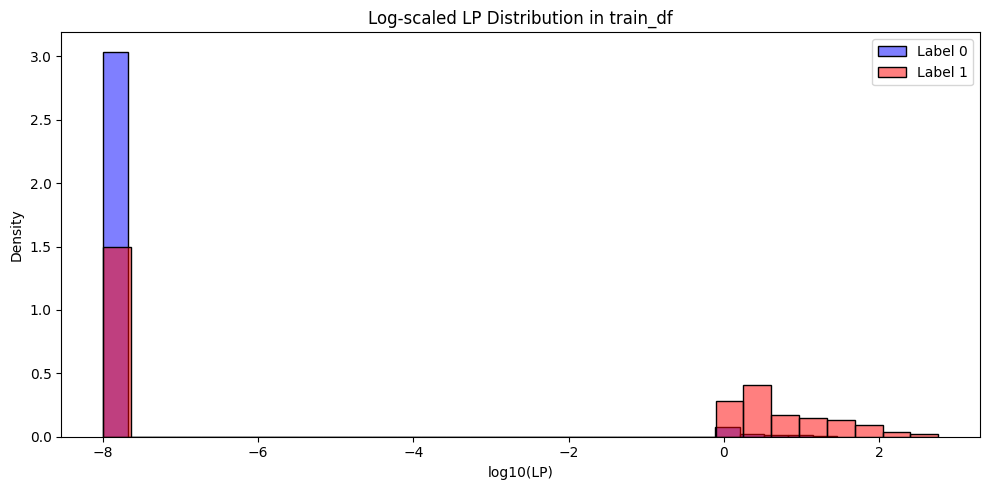

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


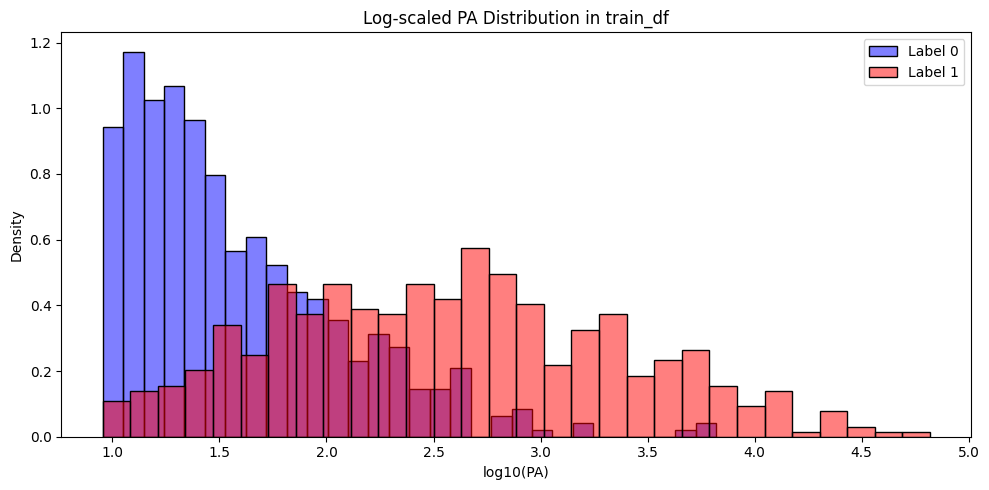

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


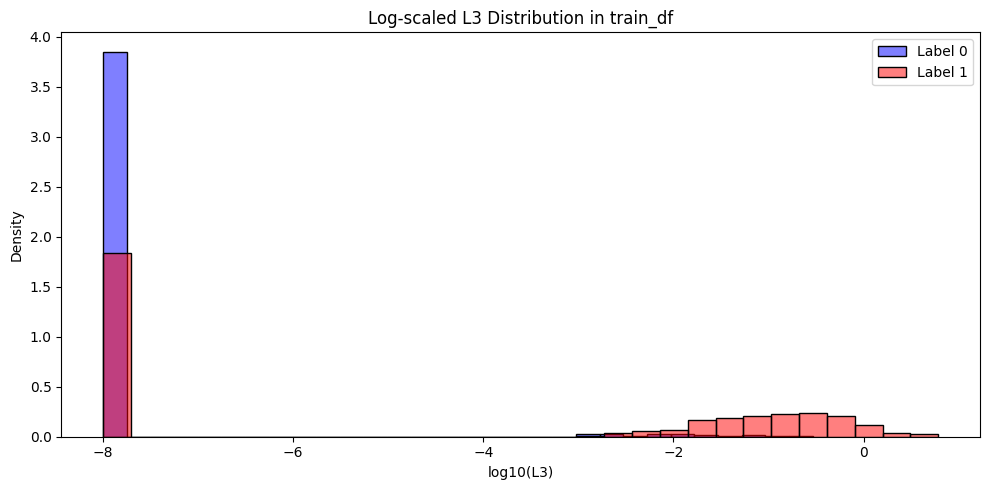

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


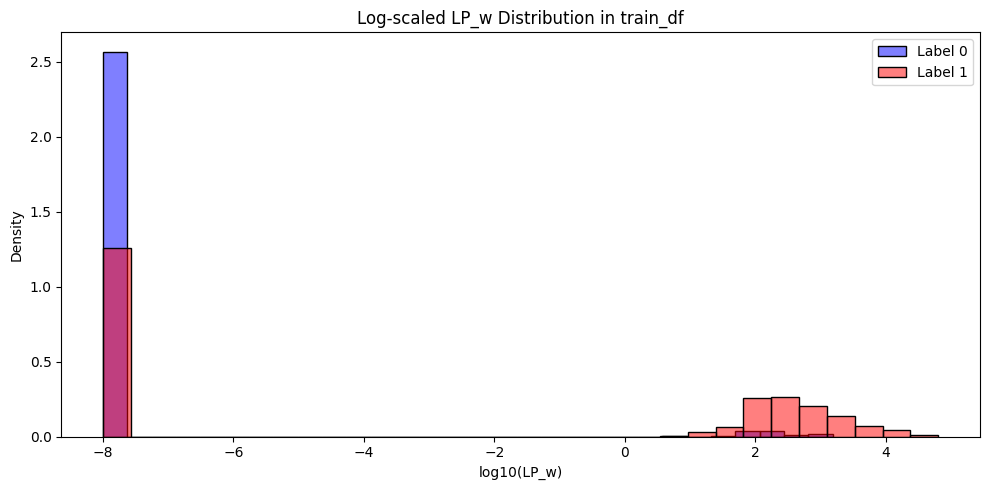

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


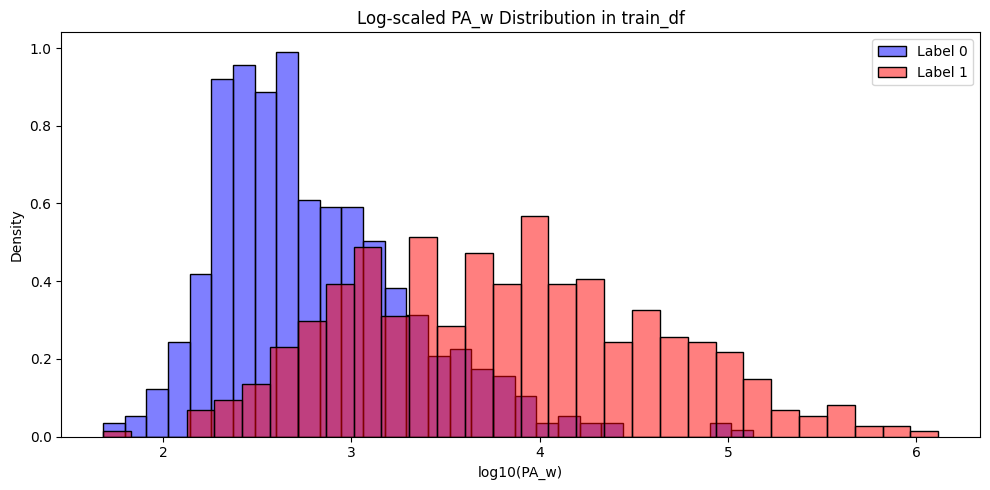

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


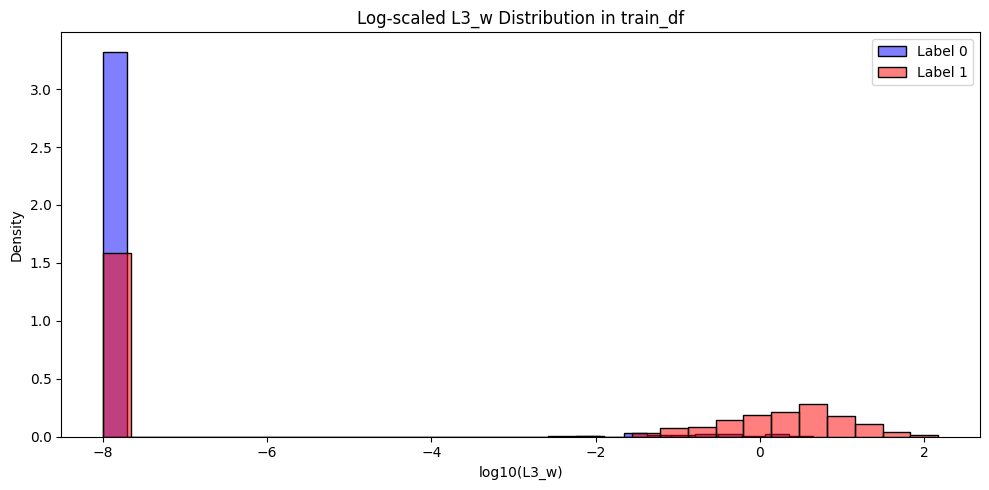

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


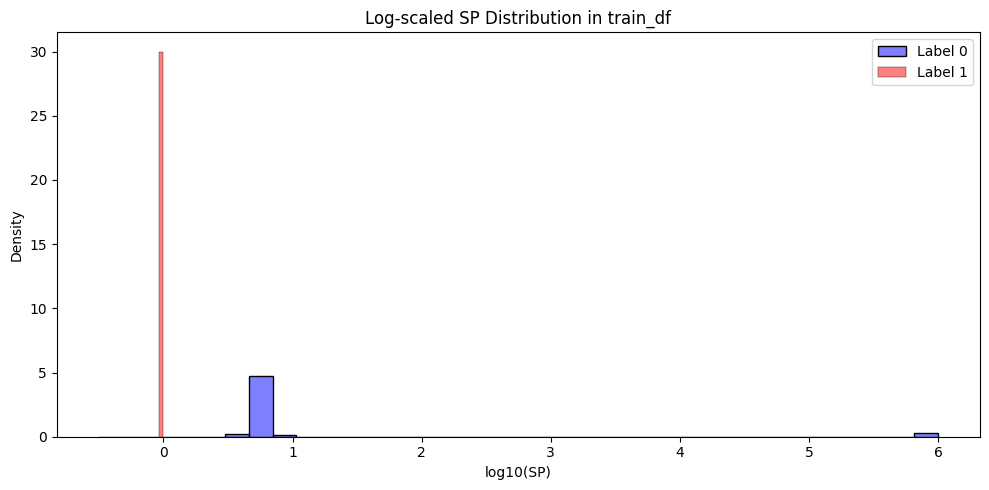

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


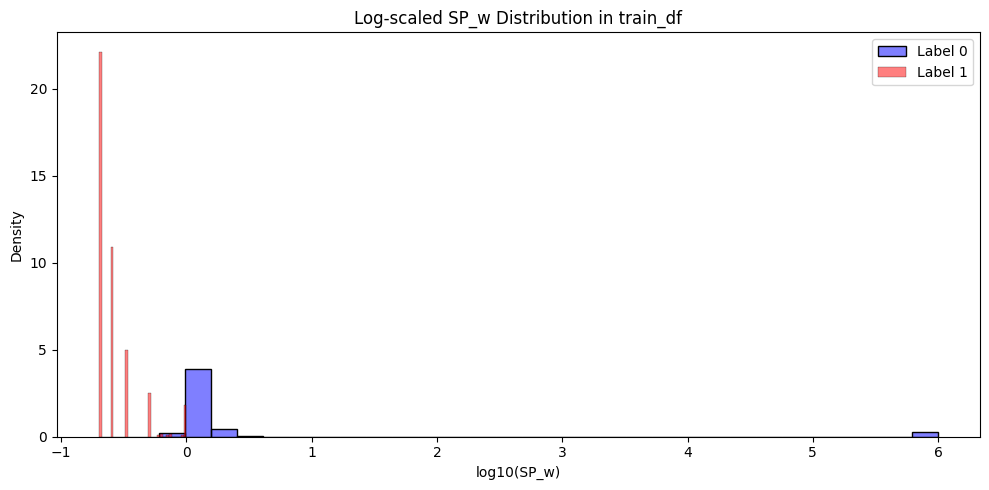


Plotting log-transformed histograms for: test_df


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


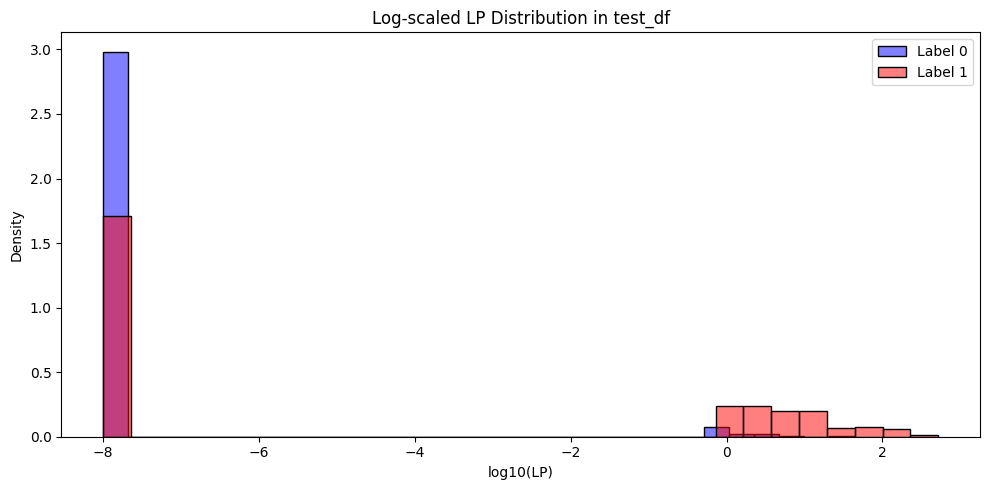

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


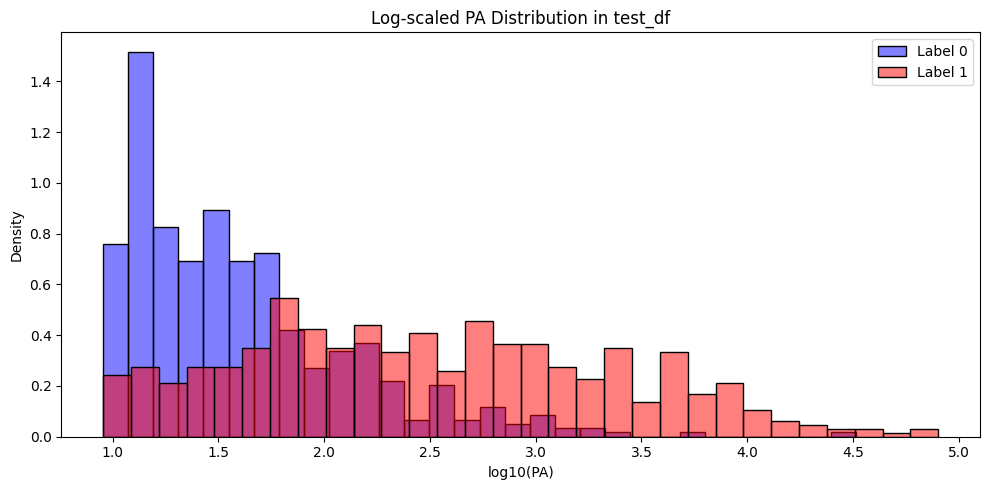

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


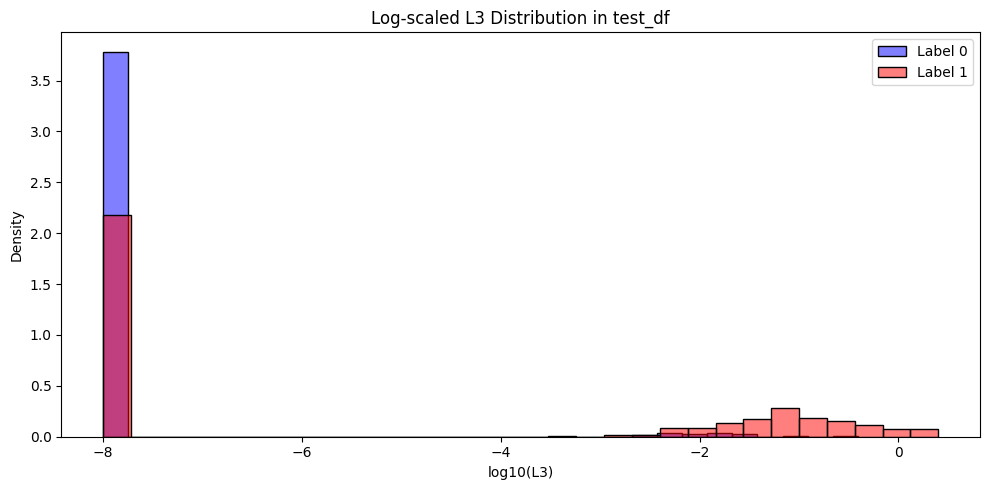

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


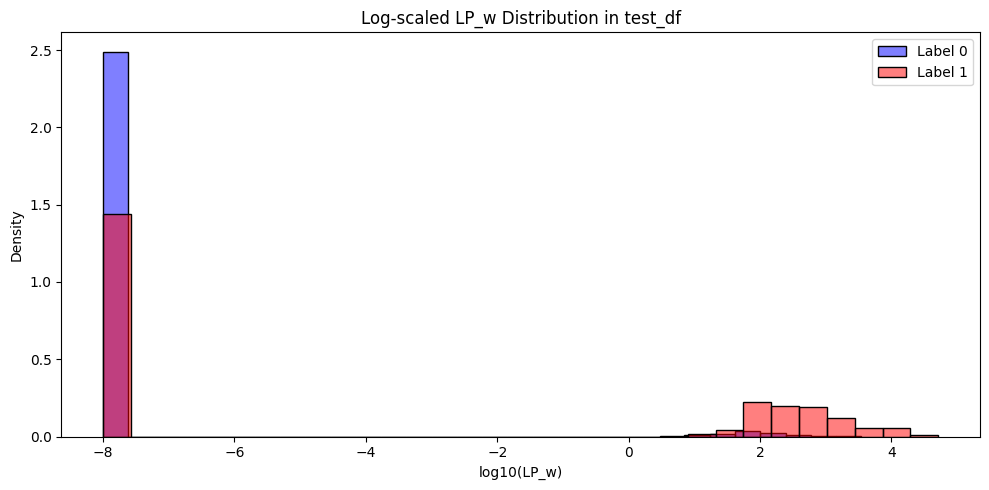

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


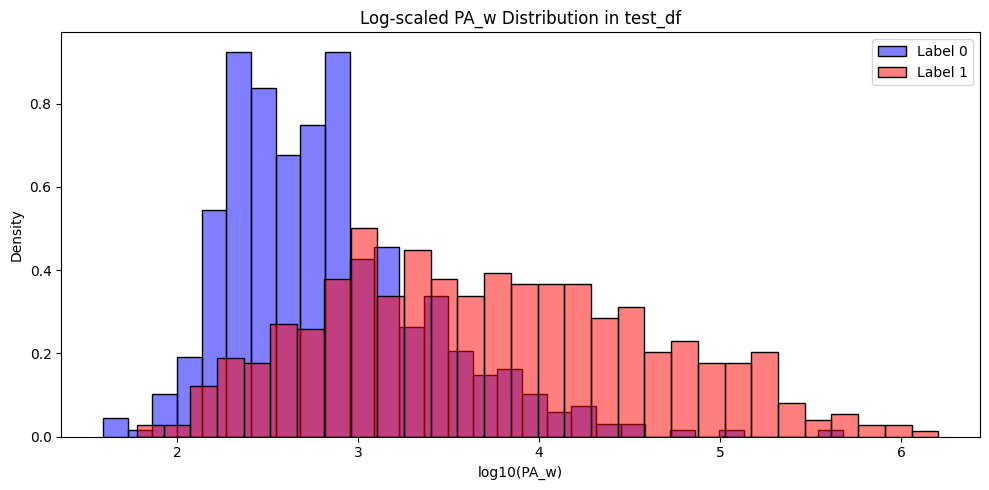

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


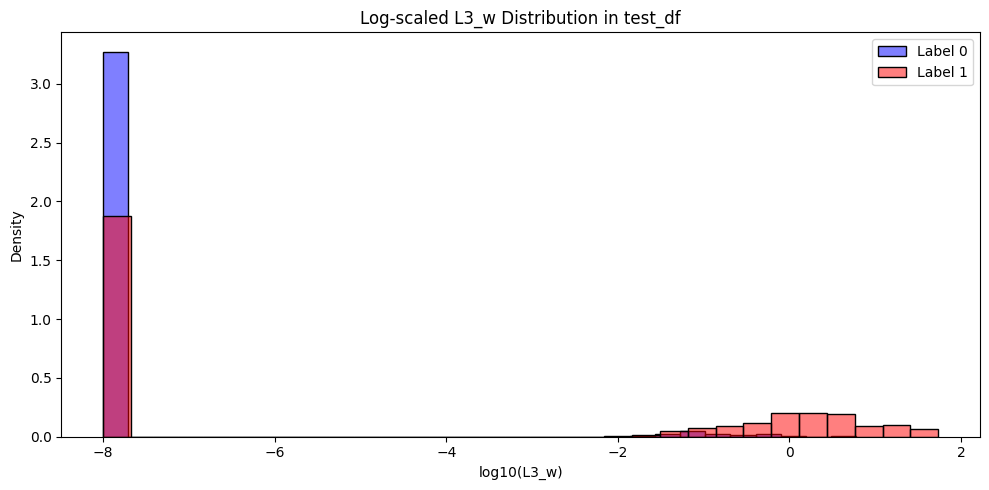

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


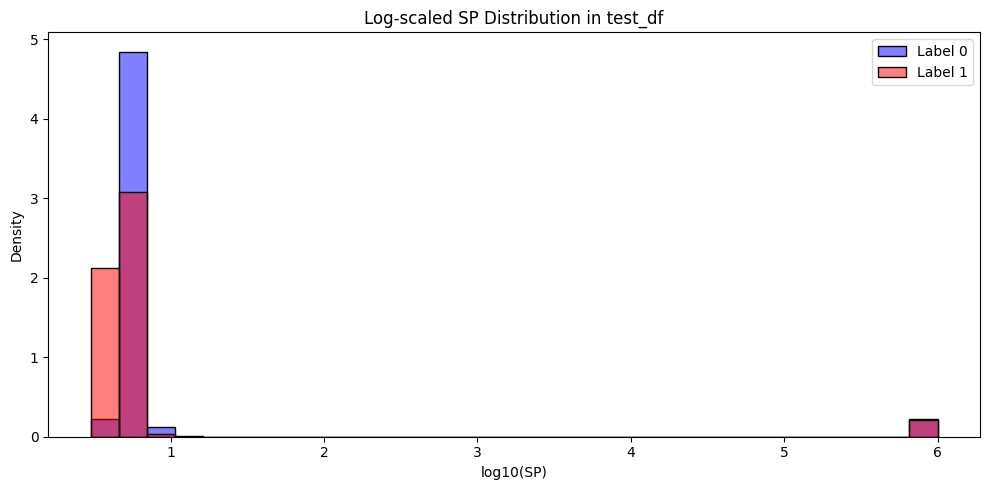

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


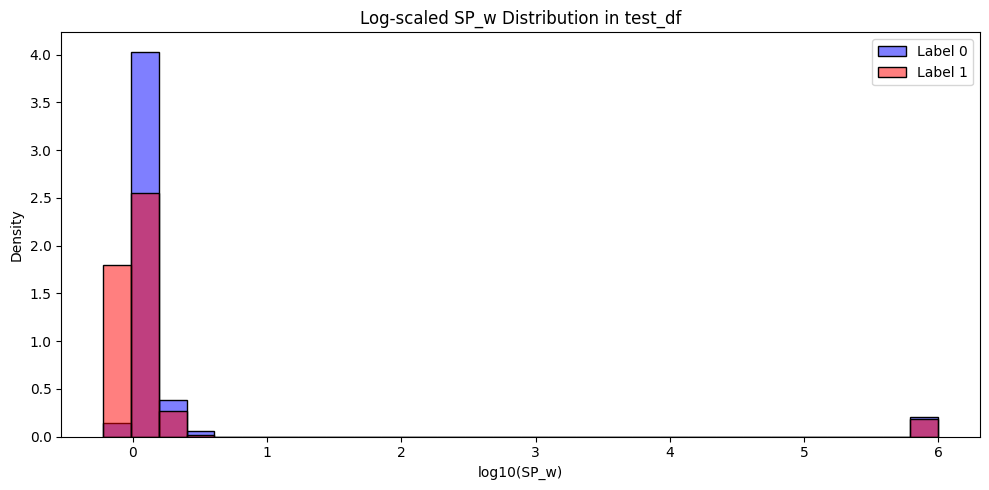

In [45]:
import numpy as np

for df_name, df in [('train_df', train_df), ('test_df', test_df)]:
    print(f"\nPlotting log-transformed histograms for: {df_name}")
    for feature in features:
        plt.figure(figsize=(10, 5))

        # Add a small constant to avoid log(0)
        epsilon = 1e-8
        x0 = np.log10(df[df['label'] == 0][feature] + epsilon)
        x1 = np.log10(df[df['label'] == 1][feature] + epsilon)

        sns.histplot(x=x0, color='blue', label='Label 0', stat='density', bins=30, alpha=0.5)
        sns.histplot(x=x1, color='red', label='Label 1', stat='density', bins=30, alpha=0.5)

        plt.title(f"Log-scaled {feature} Distribution in {df_name}")
        plt.xlabel(f"log10({feature})")
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()


In [20]:
test_df=pd.read_csv("test_df_SP.csv")

Histograms for SP columns


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


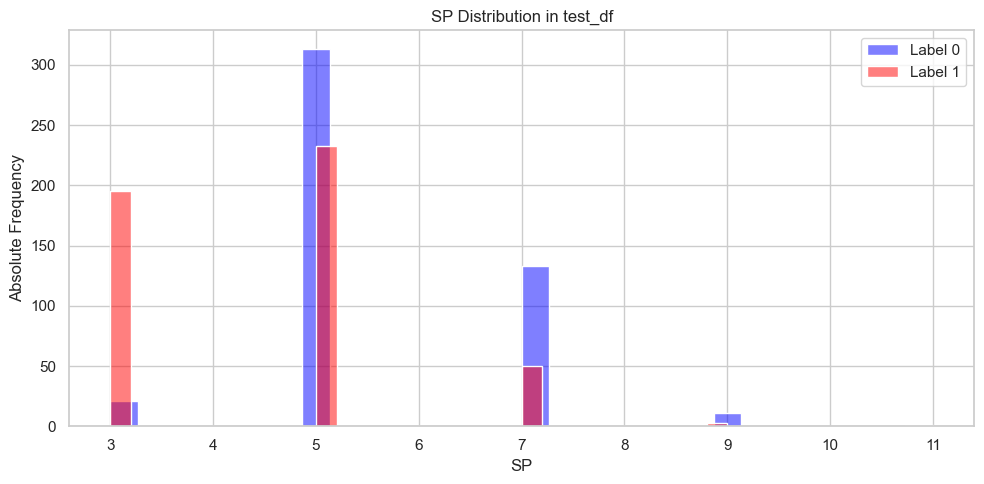

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


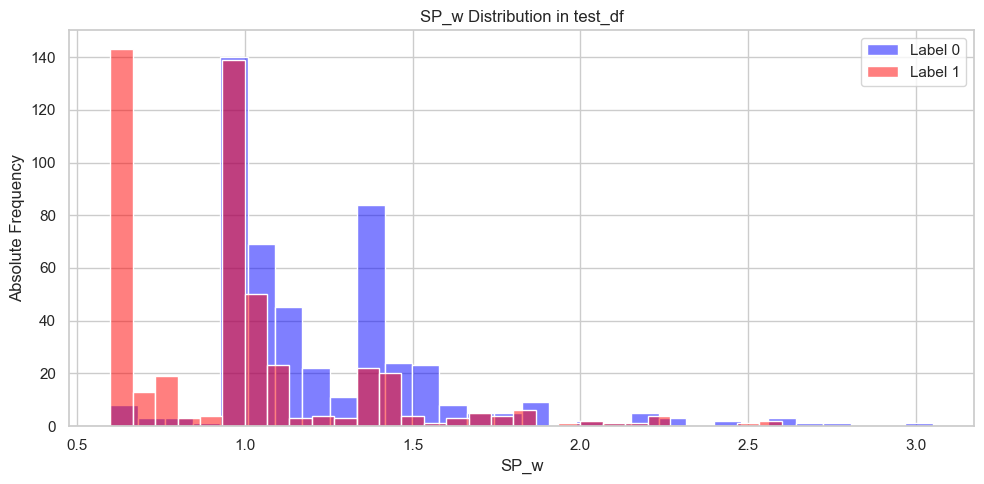

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Columns to plot
features = ['SP', 'SP_w']

print("Histograms for SP columns")
for feature in features:
    plt.figure(figsize=(10, 5))
    
    # Filter out values > 1000
    x0 = test_df[(test_df['label'] == 0) & (test_df[feature] <= 1000)][feature]
    x1 = test_df[(test_df['label'] == 1) & (test_df[feature] <= 1000)][feature]
    
    # Plot histograms
    sns.histplot(x=x0, color='blue', label='Label 0', stat='count', bins=30, alpha=0.5)
    sns.histplot(x=x1, color='red', label='Label 1', stat='count', bins=30, alpha=0.5)
    
    plt.title(f"{feature} Distribution in test_df")
    plt.xlabel(feature)
    plt.ylabel('Absolute Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Predictions

In [1]:
import os
import pandas as pd

# Raw string avoids issues with backslashes
os.chdir(r"C:\Nina\Studium Master\Porto\Network Science\Final Project")

train_df=pd.read_csv("train_df_SP.csv")
test_df=pd.read_csv("test_df_SP.csv")

In [2]:
import numpy as np

# Replace infinity for classifiers
train_df['SP'] = train_df['SP'].replace(np.inf, 1000000)
train_df['SP_w'] = train_df['SP_w'].replace(np.inf, 1000000)

test_df['SP'] = test_df['SP'].replace(np.inf, 1000000)
test_df['SP_w'] = test_df['SP_w'].replace(np.inf, 1000000)

In [9]:
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix

# Task 1: Individual feature-based predictions
from sklearn.metrics import accuracy_score, f1_score

def individual_feature_predictions_fixed_n(train_df, test_df, features, n=500):
    results = {}

    for feature in features:
        # Determine sorting direction
        ascending_order = 'SP' in feature

        # Sort train and test accordingly
        sorted_train = train_df.sort_values(by=feature, ascending=ascending_order).reset_index(drop=True)
        sorted_test = test_df.sort_values(by=feature, ascending=ascending_order).reset_index(drop=True)

        # Train predictions: top-n are 1s
        train_preds = [1 if i < n else 0 for i in range(len(sorted_train))]
        train_acc = accuracy_score(sorted_train['label'], train_preds)
        train_f1 = f1_score(sorted_train['label'], train_preds)

        # Test predictions: top-n are 1s
        test_preds = [1 if i < n else 0 for i in range(len(sorted_test))]
        test_acc = accuracy_score(sorted_test['label'], test_preds)
        test_f1 = f1_score(sorted_test['label'], test_preds)

        results[feature] = {
            'train_accuracy': train_acc,
            'train_f1': train_f1,
            'test_accuracy': test_acc,
            'test_f1': test_f1,
            'n': n
        }

    return results

from sklearn.metrics import accuracy_score, f1_score

def individual_feature_predictions_best_n(train_df, test_df, features):
    results = {}

    for feature in features:
        # Sort both train and test by the feature descending
        sorted_train = train_df.sort_values(by=feature, ascending=False).reset_index(drop=True)
        sorted_test = test_df.sort_values(by=feature, ascending=False).reset_index(drop=True)

        # Find the best n based on training accuracy
        best_acc = 0
        best_n = 0
        for n in range(1, len(sorted_train) + 1):
            preds = [1 if i < n else 0 for i in range(len(sorted_train))]
            acc = accuracy_score(sorted_train['label'], preds)
            if acc > best_acc:
                best_acc = acc
                best_n = n

        # Use best_n to make predictions on both train and test
        train_preds = [1 if i < best_n else 0 for i in range(len(sorted_train))]
        test_preds = [1 if i < best_n else 0 for i in range(len(sorted_test))]

        # Compute metrics
        train_acc = accuracy_score(sorted_train['label'], train_preds)
        train_f1 = f1_score(sorted_train['label'], train_preds)
        test_acc = accuracy_score(sorted_test['label'], test_preds)
        test_f1 = f1_score(sorted_test['label'], test_preds)

        results[feature] = {
            'train_accuracy': train_acc,
            'train_f1': train_f1,
            'test_accuracy': test_acc,
            'test_f1': test_f1,
            'n': best_n
        }

    return results

# Features to evaluate
features = ['LP', 'PA', 'L3', 'SP']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df, test_df, features)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Task 2: Train classifiers
def train_classifiers(train_df, test_df, features):
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # Prepare data
    X_train = train_df[features]
    y_train = train_df['label']
    X_test = test_df[features]
    y_test = test_df['label']
    
    # Initialize models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=500),
        'KNN': KNeighborsClassifier(),
        'XGBoost': XGBClassifier(eval_metric='logloss')
    }
    
    results = {}
    
    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)
        
        # Calculate metrics
        train_acc = accuracy_score(y_train, train_preds)
        train_f1 = f1_score(y_train, train_preds)
        test_acc = accuracy_score(y_test, test_preds)
        test_f1 = f1_score(y_test, test_preds)
        
        results[name] = {
            'train_accuracy': train_acc,
            'train_f1': train_f1,
            'test_accuracy': test_acc,
            'test_f1': test_f1
        }
    
    return results

# Run classifiers
classifier_results = train_classifiers(train_df, test_df, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Features to evaluate
features = ['LP', 'PA', 'L3']

# Run individual feature predictions
individual_results = individual_feature_predictions_best_n(train_df, test_df, features)

# Print results
print("Individual Feature Results best n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP
n: 500
Train Accuracy: 0.6600
Train F1: 0.6600
Test Accuracy: 0.6100
Test F1: 0.6100

Feature: PA
n: 500
Train Accuracy: 0.7700
Train F1: 0.7700
Test Accuracy: 0.7400
Test F1: 0.7400

Feature: L3
n: 500
Train Accuracy: 0.6480
Train F1: 0.6480
Test Accuracy: 0.6100
Test F1: 0.6100

Feature: SP
n: 500
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.6320
Test F1: 0.6320

Classifier Results:

Model: Logistic Regression
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5030
Test F1: 0.0119

Model: KNN
Train Accuracy: 0.9540
Train F1: 0.9557
Test Accuracy: 0.7260
Test F1: 0.6683

Model: XGBoost
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5000
Test F1: 0.0000
Individual Feature Results best n:

Feature: LP
n: 253
Train Accuracy: 0.7110
Train F1: 0.6162
Test Accuracy: 0.6790
Test F1: 0.5737

Feature: PA
n: 480
Train Accuracy: 0.7760
Train F1: 0.7714
Test Accuracy: 0.7380
Test F1: 0.7327

Feature: L3
n: 243
Train Accu

In [5]:
features = ['LP_w', 'PA_w', 'L3_w', 'SP_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df, test_df, features)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Run classifiers
classifier_results = train_classifiers(train_df, test_df, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Features to evaluate
features = ['LP_w', 'PA_w', 'L3_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_best_n(train_df, test_df, features)

# Print results
print("Individual Feature Results best n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP_w
n: 500
Train Accuracy: 0.6500
Train F1: 0.6500
Test Accuracy: 0.6100
Test F1: 0.6100

Feature: PA_w
n: 500
Train Accuracy: 0.7680
Train F1: 0.7680
Test Accuracy: 0.7320
Test F1: 0.7320

Feature: L3_w
n: 500
Train Accuracy: 0.6520
Train F1: 0.6520
Test Accuracy: 0.6100
Test F1: 0.6100

Feature: SP_w
n: 500
Train Accuracy: 0.9580
Train F1: 0.9580
Test Accuracy: 0.6540
Test F1: 0.6540

Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.9640
Train F1: 0.9637
Test Accuracy: 0.6530
Test F1: 0.4829

Model: KNN
Train Accuracy: 0.8500
Train F1: 0.8434
Test Accuracy: 0.6860
Test F1: 0.6549

Model: XGBoost
Train Accuracy: 0.9900
Train F1: 0.9899
Test Accuracy: 0.6190
Test F1: 0.4129
Individual Feature Results best n:

Feature: LP_w
n: 251
Train Accuracy: 0.7110
Train F1: 0.6152
Test Accuracy: 0.6630
Test F1: 0.5513

Feature: PA_w
n: 431
Train Accuracy: 0.7770
Train F1: 0.7605
Test Accuracy: 0.7390
Test F1: 0.7197

Feature: L3_w
n: 

In [ ]:
features = ['LP', 'PA', 'L3', 'LP_w', 'PA_w', 'L3_w', 'SP', 'SP_w']

# Run classifiers
classifier_results = train_classifiers(train_df, test_df, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5320
Test F1: 0.1203

Model: KNN
Train Accuracy: 0.9880
Train F1: 0.9881
Test Accuracy: 0.6760
Test F1: 0.5462

Model: XGBoost
Train Accuracy: 0.9990
Train F1: 0.9990
Test Accuracy: 0.5870
Test F1: 0.3012


In [12]:
features = ['LP', 'PA', 'L3', 'SP', 'SP_w', 'PA_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df, test_df, features, n=400)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP
n: 400
Train Accuracy: 0.6780
Train F1: 0.6422
Test Accuracy: 0.6320
Test F1: 0.5911

Feature: PA
n: 400
Train Accuracy: 0.7600
Train F1: 0.7333
Test Accuracy: 0.7320
Test F1: 0.7022

Feature: L3
n: 400
Train Accuracy: 0.6720
Train F1: 0.6356
Test Accuracy: 0.6320
Test F1: 0.5911

Feature: SP
n: 400
Train Accuracy: 0.9000
Train F1: 0.8889
Test Accuracy: 0.6360
Test F1: 0.5956

Feature: SP_w
n: 400
Train Accuracy: 0.9000
Train F1: 0.8889
Test Accuracy: 0.6680
Test F1: 0.6311

Feature: PA_w
n: 400
Train Accuracy: 0.7680
Train F1: 0.7422
Test Accuracy: 0.7280
Test F1: 0.6978


In [13]:
features = ['LP', 'PA', 'L3', 'SP', 'SP_w', 'PA_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df, test_df, features, n=300)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP
n: 300
Train Accuracy: 0.6980
Train F1: 0.6225
Test Accuracy: 0.6560
Test F1: 0.5700

Feature: PA
n: 300
Train Accuracy: 0.7380
Train F1: 0.6725
Test Accuracy: 0.7180
Test F1: 0.6475

Feature: L3
n: 300
Train Accuracy: 0.7000
Train F1: 0.6250
Test Accuracy: 0.6660
Test F1: 0.5825

Feature: SP
n: 300
Train Accuracy: 0.8000
Train F1: 0.7500
Test Accuracy: 0.6540
Test F1: 0.5675

Feature: SP_w
n: 300
Train Accuracy: 0.8000
Train F1: 0.7500
Test Accuracy: 0.6660
Test F1: 0.5825

Feature: PA_w
n: 300
Train Accuracy: 0.7420
Train F1: 0.6775
Test Accuracy: 0.7140
Test F1: 0.6425


In [14]:
features = ['LP', 'PA', 'L3', 'SP', 'SP_w', 'PA_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df, test_df, features, n=200)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP
n: 200
Train Accuracy: 0.6780
Train F1: 0.5400
Test Accuracy: 0.6700
Test F1: 0.5286

Feature: PA
n: 200
Train Accuracy: 0.6740
Train F1: 0.5343
Test Accuracy: 0.6660
Test F1: 0.5229

Feature: L3
n: 200
Train Accuracy: 0.6860
Train F1: 0.5514
Test Accuracy: 0.6700
Test F1: 0.5286

Feature: SP
n: 200
Train Accuracy: 0.7000
Train F1: 0.5714
Test Accuracy: 0.6580
Test F1: 0.5114

Feature: SP_w
n: 200
Train Accuracy: 0.7000
Train F1: 0.5714
Test Accuracy: 0.6700
Test F1: 0.5286

Feature: PA_w
n: 200
Train Accuracy: 0.6780
Train F1: 0.5400
Test Accuracy: 0.6660
Test F1: 0.5229


In [19]:
features = ['LP', 'PA', 'L3']

# Run classifiers
classifier_results = train_classifiers(train_df, test_df, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7670
Train F1: 0.7155
Test Accuracy: 0.7240
Test F1: 0.6480

Model: KNN
Train Accuracy: 0.7950
Train F1: 0.7902
Test Accuracy: 0.6990
Test F1: 0.6774

Model: XGBoost
Train Accuracy: 0.8400
Train F1: 0.8272
Test Accuracy: 0.7200
Test F1: 0.6868


In [20]:
features = ['LP_w', 'PA_w', 'L3_w']

# Run classifiers
classifier_results = train_classifiers(train_df, test_df, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7620
Train F1: 0.7032
Test Accuracy: 0.7230
Test F1: 0.6426

Model: KNN
Train Accuracy: 0.8420
Train F1: 0.8358
Test Accuracy: 0.6890
Test F1: 0.6667

Model: XGBoost
Train Accuracy: 0.8520
Train F1: 0.8391
Test Accuracy: 0.7130
Test F1: 0.6843


In [21]:
features = ['LP_w', 'PA_w', 'L3_w', 'LP', 'PA', 'L3']

# Run classifiers
classifier_results = train_classifiers(train_df, test_df, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7650
Train F1: 0.7102
Test Accuracy: 0.7230
Test F1: 0.6435

Model: KNN
Train Accuracy: 0.8350
Train F1: 0.8254
Test Accuracy: 0.7120
Test F1: 0.6849

Model: XGBoost
Train Accuracy: 0.9190
Train F1: 0.9161
Test Accuracy: 0.7210
Test F1: 0.7103


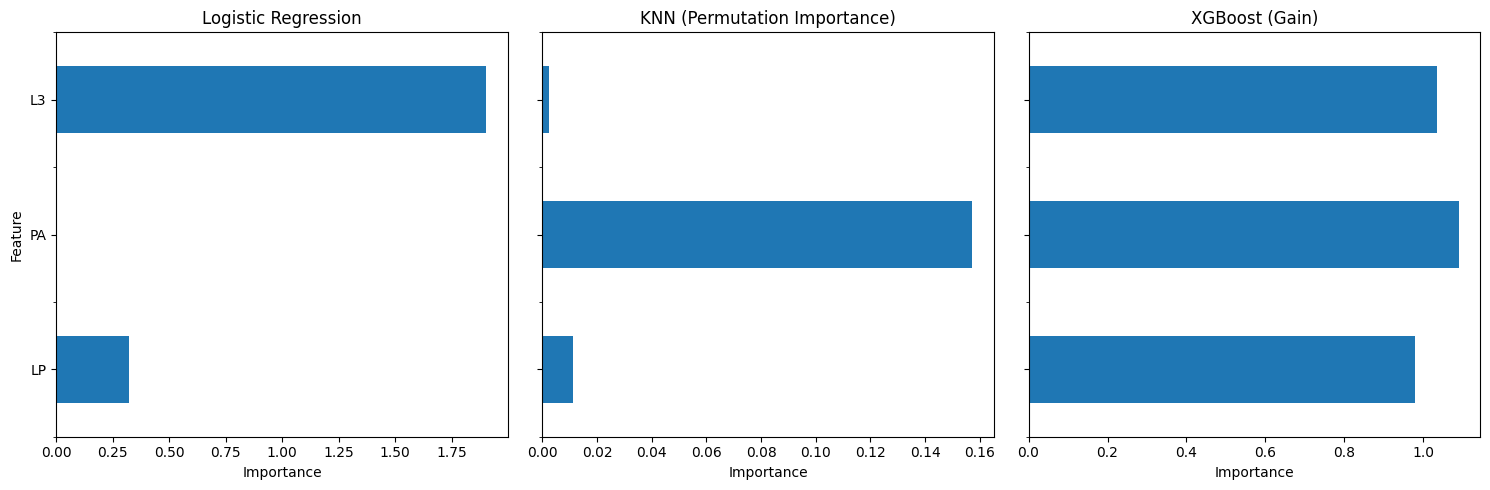

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

def train_classifiers_keepmodel(train_df, test_df, features):
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

    X_train = train_df[features]
    y_train = train_df['label']
    X_test = test_df[features]
    y_test = test_df['label']
    
    models = {
        'Logistic Regression': LogisticRegression(max_iter=500),
        'KNN': KNeighborsClassifier(),
        'XGBoost': XGBClassifier(eval_metric='logloss')
    }
    
    results = {}
    trained_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)
        
        results[name] = {
            'train_accuracy': accuracy_score(y_train, train_preds),
            'train_f1': f1_score(y_train, train_preds),
            'test_accuracy': accuracy_score(y_test, test_preds),
            'test_f1': f1_score(y_test, test_preds)
        }
        
        trained_models[name] = model  # Save model separately

    return results, trained_models, X_test, y_test


features = ['LP', 'PA', 'L3']

# Train and retrieve models
classifier_results, trained_models, X_test, y_test = train_classifiers_keepmodel(train_df, test_df, features)

# Retrieve correct models
lr_model = trained_models['Logistic Regression']
knn_model = trained_models['KNN']
xgb_model = trained_models['XGBoost']

# Compute importances
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=features)

perm_importance = permutation_importance(knn_model, X_test, y_test, n_repeats=30, random_state=42)
knn_importance = pd.Series(perm_importance.importances_mean, index=features)

xgb_importance_raw = xgb_model.get_booster().get_score(importance_type='gain')
xgb_feature_map = {f"f{i}": feat for i, feat in enumerate(features)}
xgb_importance = pd.Series({xgb_feature_map.get(k, k): v for k, v in xgb_importance_raw.items()})
xgb_importance = xgb_importance.reindex(features).fillna(0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Consistent feature order
lr_importance.reindex(features).plot.barh(ax=axes[0], title='Logistic Regression')
knn_importance.reindex(features).plot.barh(ax=axes[1], title='KNN (Permutation Importance)')
xgb_importance.reindex(features).plot.barh(ax=axes[2], title='XGBoost (Gain)')

for ax in axes:
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

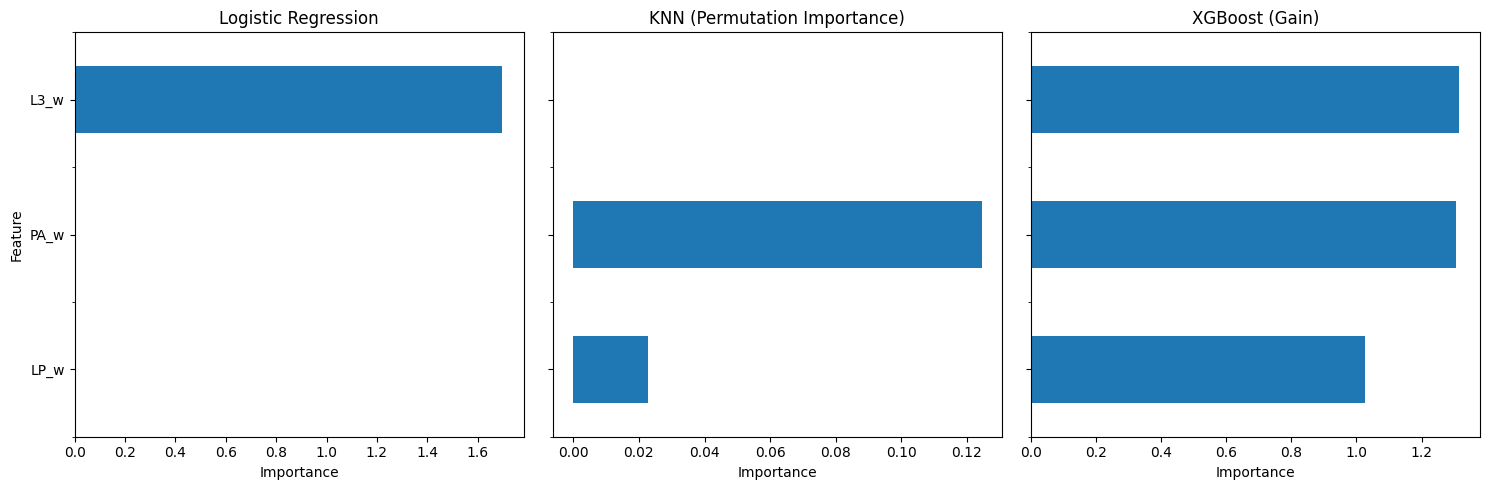

In [33]:
features = ['LP_w', 'PA_w', 'L3_w']

# Train and retrieve models
classifier_results, trained_models, X_test, y_test = train_classifiers_keepmodel(train_df, test_df, features)

# Retrieve correct models
lr_model = trained_models['Logistic Regression']
knn_model = trained_models['KNN']
xgb_model = trained_models['XGBoost']

# Compute importances
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=features)

perm_importance = permutation_importance(knn_model, X_test, y_test, n_repeats=30, random_state=42)
knn_importance = pd.Series(perm_importance.importances_mean, index=features)

xgb_importance_raw = xgb_model.get_booster().get_score(importance_type='gain')
xgb_feature_map = {f"f{i}": feat for i, feat in enumerate(features)}
xgb_importance = pd.Series({xgb_feature_map.get(k, k): v for k, v in xgb_importance_raw.items()})
xgb_importance = xgb_importance.reindex(features).fillna(0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Consistent feature order
lr_importance.reindex(features).plot.barh(ax=axes[0], title='Logistic Regression')
knn_importance.reindex(features).plot.barh(ax=axes[1], title='KNN (Permutation Importance)')
xgb_importance.reindex(features).plot.barh(ax=axes[2], title='XGBoost (Gain)')

for ax in axes:
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

# Robustness Checks

In [3]:
import networkx as nx
import os

# Raw string avoids issues with backslashes
os.chdir(r"C:\Nina\Studium Master\Porto\Network Science\Final Project")

import pickle

# Load G from 'saved_graph_original.pickle'
with open('saved_graph_original.pickle', 'rb') as f:
    data_original = pickle.load(f)
    G = data_original['G_original']

# Load G_train and G_test from 'time_split_graphs.pickle'
with open('time_split_graphs.pickle', 'rb') as f:
    data_split = pickle.load(f)
    G_train = data_split['G_train']
    G_test = data_split['G_test']

In [ ]:
# Usage

random.seed(32)
train_df2, test_df2 = sample_pairs_with_min_edges(
    G_train=G_train,
    G_test=G_test,
    users=users,
    products=products,
    n_samples=500,
    min_edges=3
)

random.seed(12)  
train_df3, test_df3 = sample_pairs_with_min_edges(
    G_train=G_train,
    G_test=G_test,
    users=users,
    products=products,
    n_samples=500,
    min_edges=3
)

train_df2.to_csv("train_df2.csv")
train_df3.to_csv("train_df3.csv")
test_df2.to_csv("test_df2.csv")
test_df3.to_csv("test_df3.csv")

In [8]:
def compute_all_features(df, G, output_filename):
    df['PA'] = df.apply(lambda row: PA(G, row['node1'], row['node2']), axis=1)
    df.to_csv(output_filename, index=False)
    df['LP_w'] = df.apply(lambda row: weighted_LP_length_3(G, row['node1'], row['node2']), axis=1)
    df.to_csv(output_filename, index=False)
    df['PA_w'] = df.apply(lambda row: PA_w(G, row['node1'], row['node2']), axis=1)
    df.to_csv(output_filename, index=False)
    df['L3_w'] = df.apply(lambda row: L3_weighted(G, row['node1'], row['node2']), axis=1)
    df.to_csv(output_filename, index=False)
    df['L3'] = df.apply(lambda row: L3_unweighted(G, row['node1'], row['node2']), axis=1)
    df.to_csv(output_filename, index=False)
    df['LP'] = df.apply(lambda row: count_paths_length_3(G, row['node1'], row['node2']), axis=1)
    df.to_csv(output_filename, index=False)
    df['SP'] = compute_unweighted_shortest_path_lengths(df, G)
    df.to_csv(output_filename, index=False)
    df['SP_w'] = compute_weighted_shortest_path_lengths(df, G)
    df.to_csv(output_filename, index=False)
    df['SP'] = df['SP'].fillna(np.inf)
    df['SP_w'] = df['SP_w'].fillna(np.inf)
    df.to_csv(output_filename, index=False)

# Apply to all datasets
compute_all_features(train_df2, G_train, "train_df2.csv")
compute_all_features(test_df2, G_train, "test_df2.csv")
compute_all_features(train_df3, G_train, "train_df3.csv")
compute_all_features(test_df3, G_train, "test_df3.csv")

In [1]:
import os
import pandas as pd

# Raw string avoids issues with backslashes
os.chdir(r"C:\Nina\Studium Master\Porto\Network Science\Final Project")

train_df2 = pd.read_csv("train_df2.csv")
train_df3 = pd.read_csv("train_df3.csv")
test_df2 = pd.read_csv("test_df2.csv")
test_df3 = pd.read_csv("test_df3.csv")

In [2]:
features = ['LP', 'PA', 'L3', 'LP_w', 'PA_w', 'L3_w', 'SP', 'SP_w']

for df_name, df in [('train_df2', train_df2), ('test_df2', test_df2)]:
    print(f"\nUnique values and counts in {df_name}:")
    for col in features:
        print(f"\nColumn: {col}")
        print(df[col].value_counts(dropna=False))


Unique values and counts in train_df2:

Column: LP
LP
0      742
1       63
2       31
3       16
4       15
      ... 
61       1
32       1
257      1
55       1
38       1
Name: count, Length: 65, dtype: int64

Column: PA
PA
12       52
9        38
15       38
18       29
24       23
         ..
249       1
780       1
7065      1
672       1
24738     1
Name: count, Length: 414, dtype: int64

Column: L3
L3
0.000000    742
0.060193      2
0.028638      1
0.160314      1
0.400875      1
           ... 
0.189474      1
0.009850      1
0.002843      1
0.309251      1
0.028908      1
Name: count, Length: 258, dtype: int64

Column: LP_w
LP_w
0.0       742
100.0      18
125.0      11
225.0       8
30.0        7
         ... 
164.0       1
3395.0      1
937.0       1
760.0       1
72.0        1
Name: count, Length: 183, dtype: int64

Column: PA_w
PA_w
240.0     10
180.0      9
195.0      8
260.0      7
360.0      7
          ..
616.0      1
255.0      1
308.0      1
5673.0     1
242.0    

In [3]:
for df_name, df in [('train_df3', train_df3), ('test_df3', test_df3)]:
    print(f"\nUnique values and counts in {df_name}:")
    for col in features:
        print(f"\nColumn: {col}")
        print(df[col].value_counts(dropna=False))


Unique values and counts in train_df3:

Column: LP
LP
0      741
1       83
2       42
3       19
4       16
5       11
6        7
8        5
11       5
10       4
13       4
9        4
7        4
12       2
28       2
16       2
17       2
14       2
26       2
18       2
20       2
23       2
743      1
33       1
426      1
15       1
49       1
68       1
258      1
29       1
475      1
21       1
31       1
43       1
64       1
128      1
39       1
138      1
158      1
53       1
610      1
112      1
110      1
60       1
45       1
101      1
36       1
142      1
96       1
146      1
24       1
30       1
37       1
34       1
22       1
122      1
279      1
175      1
69       1
Name: count, dtype: int64

Column: PA
PA
12      54
9       54
15      28
18      24
24      23
        ..
1812     1
342      1
99       1
4879     1
976      1
Name: count, Length: 393, dtype: int64

Column: L3
L3
0.000000    741
0.408248      3
0.102062      2
0.158114      2
0.204124      2



Plotting log-transformed histograms for: train_df2


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


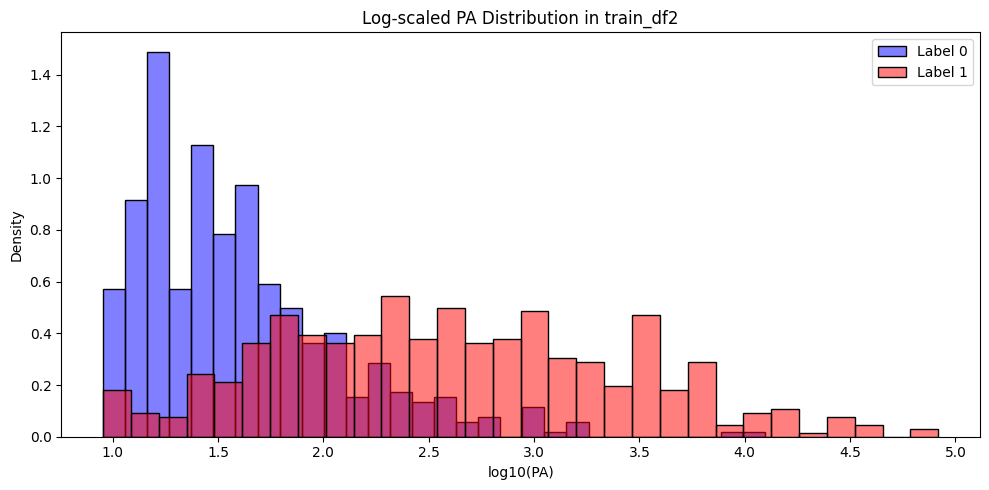

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


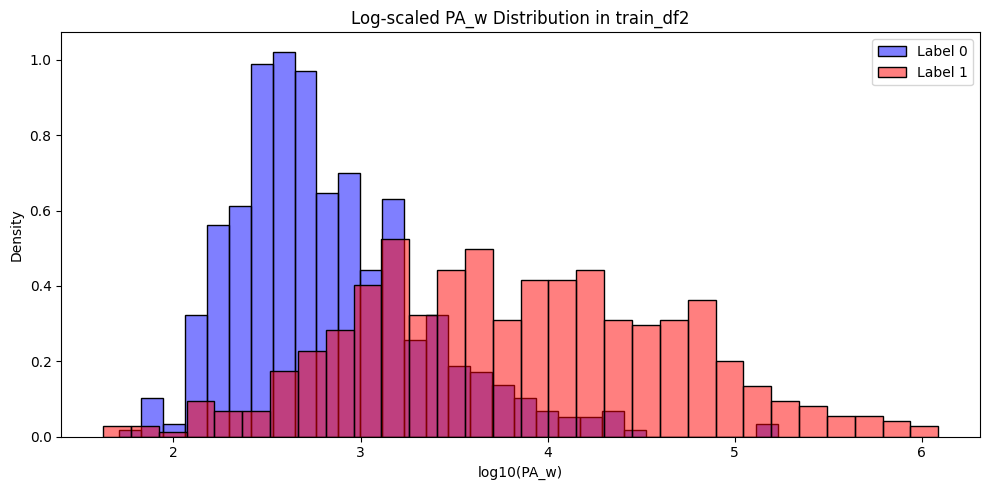


Plotting log-transformed histograms for: test_df2


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


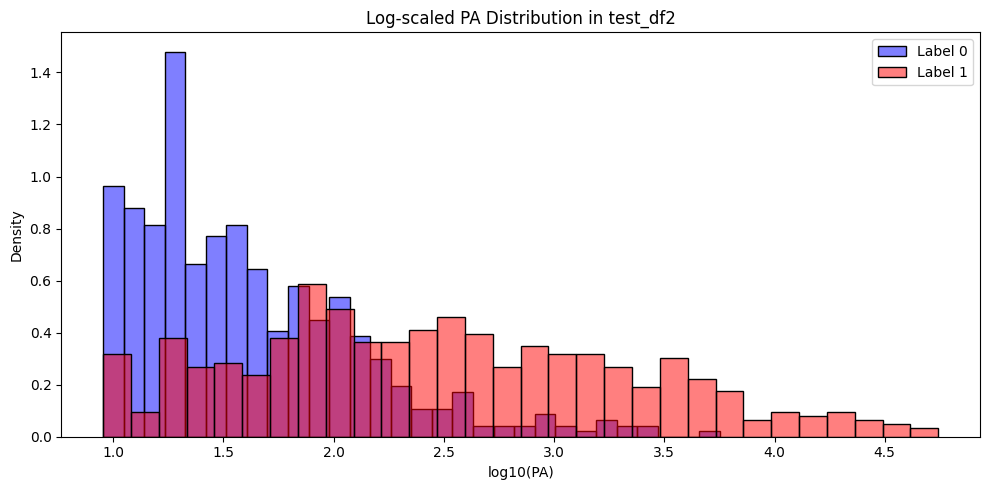

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


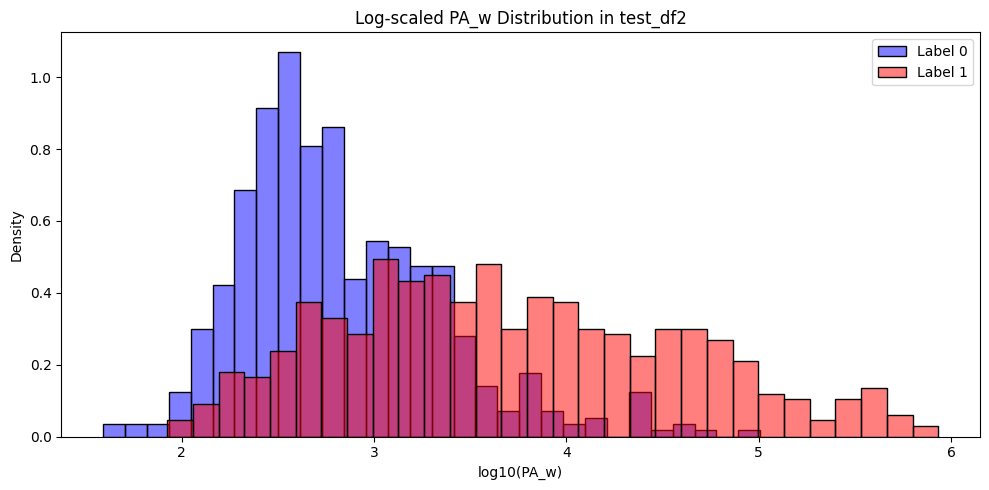

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

features=['PA','PA_w']

for df_name, df in [('train_df2', train_df2), ('test_df2', test_df2)]:
    print(f"\nPlotting log-transformed histograms for: {df_name}")
    for feature in features:
        plt.figure(figsize=(10, 5))

        # Add a small constant to avoid log(0)
        epsilon = 1e-8
        x0 = np.log10(df[df['label'] == 0][feature] + epsilon)
        x1 = np.log10(df[df['label'] == 1][feature] + epsilon)

        sns.histplot(x=x0, color='blue', label='Label 0', stat='density', bins=30, alpha=0.5)
        sns.histplot(x=x1, color='red', label='Label 1', stat='density', bins=30, alpha=0.5)

        plt.title(f"Log-scaled {feature} Distribution in {df_name}")
        plt.xlabel(f"log10({feature})")
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()


Plotting log-transformed histograms for: train_df3


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


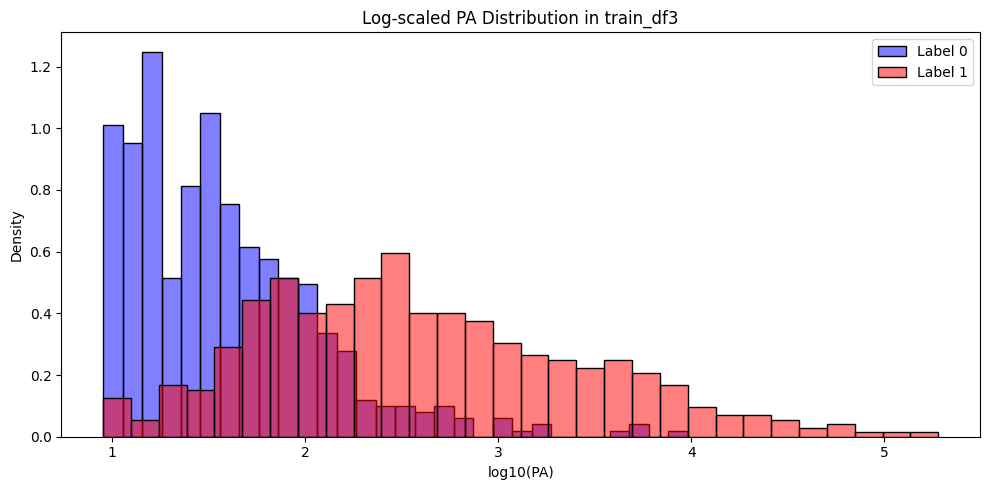

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


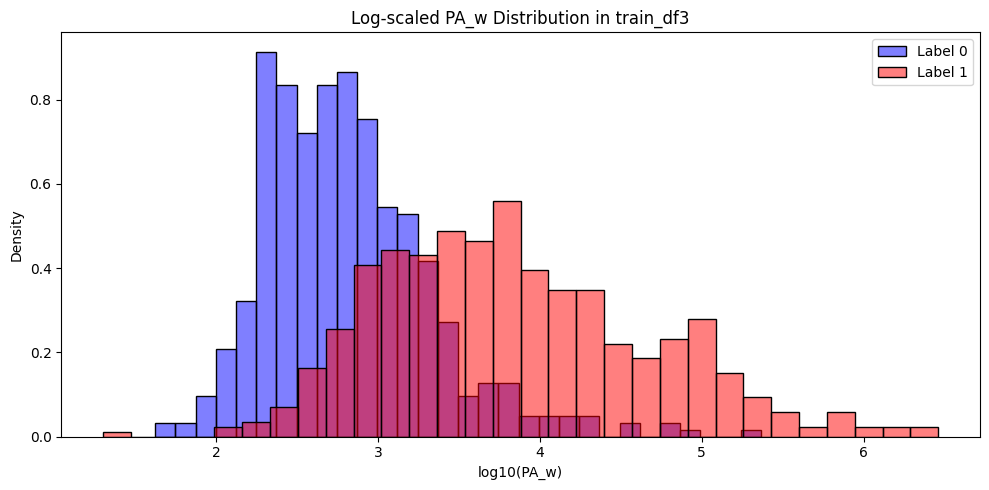


Plotting log-transformed histograms for: test_df3


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


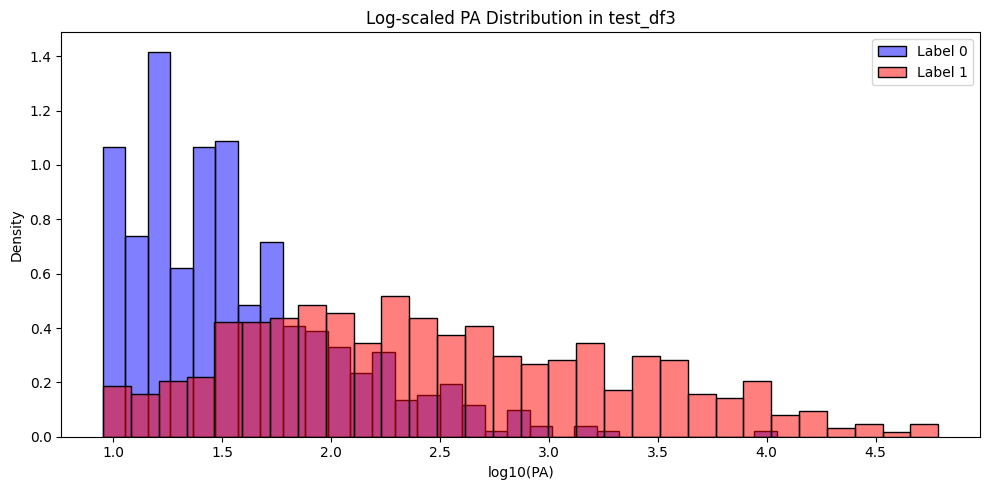

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


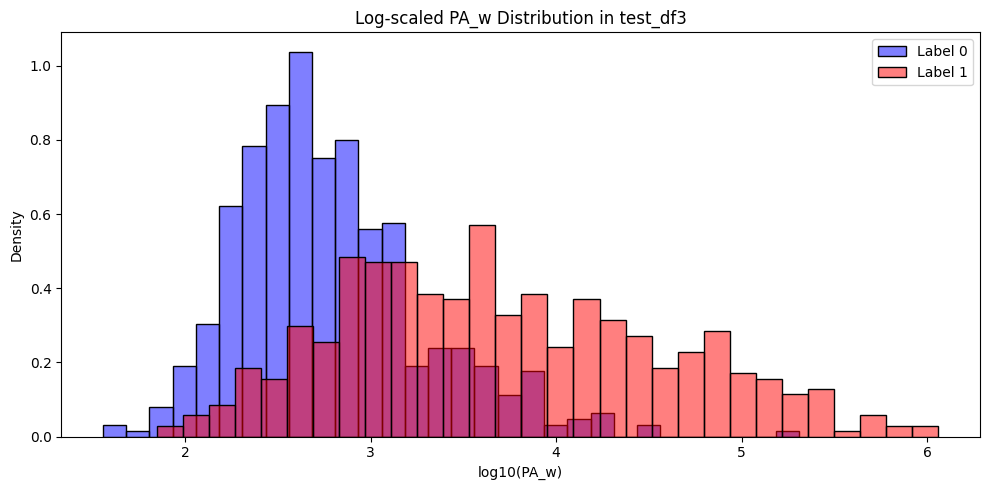

In [8]:
for df_name, df in [('train_df3', train_df3), ('test_df3', test_df3)]:
    print(f"\nPlotting log-transformed histograms for: {df_name}")
    for feature in features:
        plt.figure(figsize=(10, 5))

        # Add a small constant to avoid log(0)
        epsilon = 1e-8
        x0 = np.log10(df[df['label'] == 0][feature] + epsilon)
        x1 = np.log10(df[df['label'] == 1][feature] + epsilon)

        sns.histplot(x=x0, color='blue', label='Label 0', stat='density', bins=30, alpha=0.5)
        sns.histplot(x=x1, color='red', label='Label 1', stat='density', bins=30, alpha=0.5)

        plt.title(f"Log-scaled {feature} Distribution in {df_name}")
        plt.xlabel(f"log10({feature})")
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [9]:
# Replace infinity for classifiers in train_df2 and test_df2
train_df2['SP'] = train_df2['SP'].replace(np.inf, 1000000)
train_df2['SP_w'] = train_df2['SP_w'].replace(np.inf, 1000000)

test_df2['SP'] = test_df2['SP'].replace(np.inf, 1000000)
test_df2['SP_w'] = test_df2['SP_w'].replace(np.inf, 1000000)

# Replace infinity for classifiers in train_df3 and test_df3
train_df3['SP'] = train_df3['SP'].replace(np.inf, 1000000)
train_df3['SP_w'] = train_df3['SP_w'].replace(np.inf, 1000000)

test_df3['SP'] = test_df3['SP'].replace(np.inf, 1000000)
test_df3['SP_w'] = test_df3['SP_w'].replace(np.inf, 1000000)

Histograms for SP columns


c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


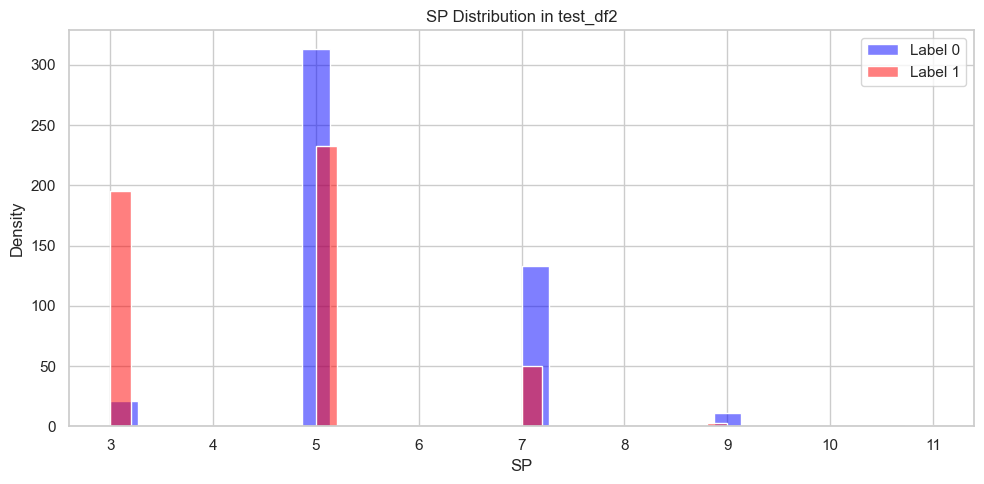

c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


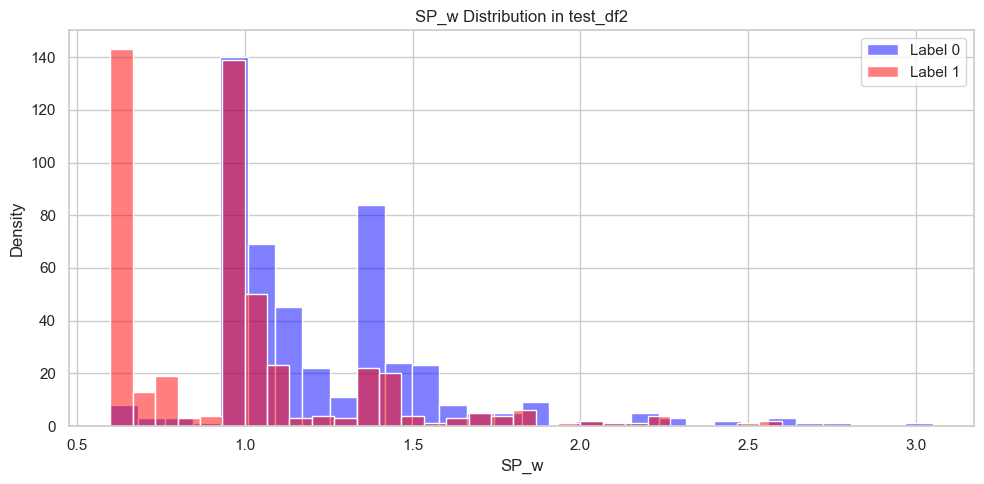

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Columns to plot
features = ['SP', 'SP_w']

print("Histograms for SP columns")
for feature in features:
    plt.figure(figsize=(10, 5))
    
    # Filter out values > 1000
    x0 = test_df[(test_df['label'] == 0) & (test_df[feature] <= 1000)][feature]
    x1 = test_df[(test_df['label'] == 1) & (test_df[feature] <= 1000)][feature]
    
    # Plot histograms
    sns.histplot(x=x0, color='blue', label='Label 0', stat='count', bins=30, alpha=0.5)
    sns.histplot(x=x1, color='red', label='Label 1', stat='count', bins=30, alpha=0.5)
    
    plt.title(f"{feature} Distribution in test_df2")
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [11]:
# Features to evaluate
features = ['LP', 'PA', 'L3', 'SP']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df2, test_df2, features)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Run classifiers
classifier_results = train_classifiers(train_df2, test_df2, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Features to evaluate
features = ['LP', 'PA', 'L3']

# Run individual feature predictions
individual_results = individual_feature_predictions_best_n(train_df2, test_df2, features)

# Print results
print("Individual Feature Results best n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP
n: 500
Train Accuracy: 0.6480
Train F1: 0.6480
Test Accuracy: 0.5980
Test F1: 0.5980

Feature: PA
n: 500
Train Accuracy: 0.7820
Train F1: 0.7820
Test Accuracy: 0.7320
Test F1: 0.7320

Feature: L3
n: 500
Train Accuracy: 0.6480
Train F1: 0.6480
Test Accuracy: 0.6100
Test F1: 0.6100

Feature: SP
n: 500
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.6380
Test F1: 0.6380

Classifier Results:

Model: Logistic Regression
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5040
Test F1: 0.0159

Model: KNN
Train Accuracy: 0.9570
Train F1: 0.9585
Test Accuracy: 0.7260
Test F1: 0.6667

Model: XGBoost
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5000
Test F1: 0.0000
Individual Feature Results best n:

Feature: LP
n: 263
Train Accuracy: 0.7110
Train F1: 0.6212
Test Accuracy: 0.6810
Test F1: 0.5819

Feature: PA
n: 477
Train Accuracy: 0.7890
Train F1: 0.7840
Test Accuracy: 0.7350
Test F1: 0.7288

Feature: L3
n: 266
Train Accu

In [12]:
# Features to evaluate
features = ['LP', 'PA', 'L3', 'SP']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df3, test_df3, features)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Run classifiers
classifier_results = train_classifiers(train_df3, test_df3, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Features to evaluate
features = ['LP', 'PA', 'L3']

# Run individual feature predictions
individual_results = individual_feature_predictions_best_n(train_df3, test_df3, features)

# Print results
print("Individual Feature Results best n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP
n: 500
Train Accuracy: 0.6380
Train F1: 0.6380
Test Accuracy: 0.5900
Test F1: 0.5900

Feature: PA
n: 500
Train Accuracy: 0.7720
Train F1: 0.7720
Test Accuracy: 0.7560
Test F1: 0.7560

Feature: L3
n: 500
Train Accuracy: 0.6380
Train F1: 0.6380
Test Accuracy: 0.5900
Test F1: 0.5900

Feature: SP
n: 500
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.6200
Test F1: 0.6200

Classifier Results:

Model: Logistic Regression
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5150
Test F1: 0.0583

Model: KNN
Train Accuracy: 0.9690
Train F1: 0.9699
Test Accuracy: 0.7190
Test F1: 0.6577

Model: XGBoost
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5000
Test F1: 0.0000
Individual Feature Results best n:

Feature: LP
n: 259
Train Accuracy: 0.7070
Train F1: 0.6140
Test Accuracy: 0.6510
Test F1: 0.5402

Feature: PA
n: 429
Train Accuracy: 0.7890
Train F1: 0.7729
Test Accuracy: 0.7510
Test F1: 0.7320

Feature: L3
n: 238
Train Accu

In [13]:
features = ['LP_w', 'PA_w', 'L3_w', 'SP_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df2, test_df2, features)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Run classifiers
classifier_results = train_classifiers(train_df2, test_df2, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Features to evaluate
features = ['LP_w', 'PA_w', 'L3_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_best_n(train_df2, test_df2, features)

# Print results
print("Individual Feature Results best n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP_w
n: 500
Train Accuracy: 0.6480
Train F1: 0.6480
Test Accuracy: 0.5980
Test F1: 0.5980

Feature: PA_w
n: 500
Train Accuracy: 0.7760
Train F1: 0.7760
Test Accuracy: 0.7220
Test F1: 0.7220

Feature: L3_w
n: 500
Train Accuracy: 0.6480
Train F1: 0.6480
Test Accuracy: 0.6060
Test F1: 0.6060

Feature: SP_w
n: 500
Train Accuracy: 0.9660
Train F1: 0.9660
Test Accuracy: 0.6660
Test F1: 0.6660

Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.9710
Train F1: 0.9707
Test Accuracy: 0.6570
Test F1: 0.4919

Model: KNN
Train Accuracy: 0.8400
Train F1: 0.8323
Test Accuracy: 0.7180
Test F1: 0.6839

Model: XGBoost
Train Accuracy: 0.9900
Train F1: 0.9899
Test Accuracy: 0.6070
Test F1: 0.3752
Individual Feature Results best n:

Feature: LP_w
n: 256
Train Accuracy: 0.7120
Train F1: 0.6190
Test Accuracy: 0.6860
Test F1: 0.5847

Feature: PA_w
n: 428
Train Accuracy: 0.7820
Train F1: 0.7651
Test Accuracy: 0.7240
Test F1: 0.7026

Feature: L3_w
n: 

In [14]:
features = ['LP_w', 'PA_w', 'L3_w', 'SP_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df3, test_df3, features)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Run classifiers
classifier_results = train_classifiers(train_df3, test_df3, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

# Features to evaluate
features = ['LP_w', 'PA_w', 'L3_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_best_n(train_df3, test_df3, features)

# Print results
print("Individual Feature Results best n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP_w
n: 500
Train Accuracy: 0.6380
Train F1: 0.6380
Test Accuracy: 0.5900
Test F1: 0.5900

Feature: PA_w
n: 500
Train Accuracy: 0.7760
Train F1: 0.7760
Test Accuracy: 0.7520
Test F1: 0.7520

Feature: L3_w
n: 500
Train Accuracy: 0.6380
Train F1: 0.6380
Test Accuracy: 0.5900
Test F1: 0.5900

Feature: SP_w
n: 500
Train Accuracy: 0.9620
Train F1: 0.9620
Test Accuracy: 0.6400
Test F1: 0.6400

Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.9650
Train F1: 0.9648
Test Accuracy: 0.6340
Test F1: 0.4471

Model: KNN
Train Accuracy: 0.8370
Train F1: 0.8318
Test Accuracy: 0.7470
Test F1: 0.7247

Model: XGBoost
Train Accuracy: 0.9880
Train F1: 0.9879
Test Accuracy: 0.6260
Test F1: 0.4101
Individual Feature Results best n:

Feature: LP_w
n: 277
Train Accuracy: 0.7090
Train F1: 0.6255
Test Accuracy: 0.6510
Test F1: 0.5508

Feature: PA_w
n: 473
Train Accuracy: 0.7870
Train F1: 0.7811
Test Accuracy: 0.7530
Test F1: 0.7461

Feature: L3_w
n: 

In [15]:
features = ['LP', 'PA', 'L3', 'SP', 'SP_w', 'PA_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df2, test_df2, features, n=300)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP
n: 300
Train Accuracy: 0.7000
Train F1: 0.6250
Test Accuracy: 0.6700
Test F1: 0.5875

Feature: PA
n: 300
Train Accuracy: 0.7420
Train F1: 0.6775
Test Accuracy: 0.7200
Test F1: 0.6500

Feature: L3
n: 300
Train Accuracy: 0.6960
Train F1: 0.6200
Test Accuracy: 0.6640
Test F1: 0.5800

Feature: SP
n: 300
Train Accuracy: 0.8000
Train F1: 0.7500
Test Accuracy: 0.6720
Test F1: 0.5900

Feature: SP_w
n: 300
Train Accuracy: 0.8000
Train F1: 0.7500
Test Accuracy: 0.6820
Test F1: 0.6025

Feature: PA_w
n: 300
Train Accuracy: 0.7380
Train F1: 0.6725
Test Accuracy: 0.7160
Test F1: 0.6450


In [16]:
features = ['LP', 'PA', 'L3', 'SP', 'SP_w', 'PA_w']

# Run individual feature predictions
individual_results = individual_feature_predictions_fixed_n(train_df3, test_df3, features, n=300)

# Print results
print("Individual Feature Results fixed n:")
for feature, metrics in individual_results.items():
    print(f"\nFeature: {feature}")
    print(f"n: {metrics['n']}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")

Individual Feature Results fixed n:

Feature: LP
n: 300
Train Accuracy: 0.6980
Train F1: 0.6225
Test Accuracy: 0.6460
Test F1: 0.5575

Feature: PA
n: 300
Train Accuracy: 0.7440
Train F1: 0.6800
Test Accuracy: 0.7180
Test F1: 0.6475

Feature: L3
n: 300
Train Accuracy: 0.6940
Train F1: 0.6175
Test Accuracy: 0.6400
Test F1: 0.5500

Feature: SP
n: 300
Train Accuracy: 0.8000
Train F1: 0.7500
Test Accuracy: 0.6600
Test F1: 0.5750

Feature: SP_w
n: 300
Train Accuracy: 0.8000
Train F1: 0.7500
Test Accuracy: 0.6520
Test F1: 0.5650

Feature: PA_w
n: 300
Train Accuracy: 0.7380
Train F1: 0.6725
Test Accuracy: 0.7160
Test F1: 0.6450


In [27]:
features = ['LP', 'PA', 'L3', 'LP_w', 'PA_w', 'L3_w', 'SP', 'SP_w']

# Run classifiers
classifier_results = train_classifiers(train_df2, test_df2, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5510
Test F1: 0.1851

Model: KNN
Train Accuracy: 0.8280
Train F1: 0.8189
Test Accuracy: 0.7360
Test F1: 0.7054

Model: XGBoost
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5000
Test F1: 0.0000


In [28]:
features = ['LP', 'PA', 'L3', 'LP_w', 'PA_w', 'L3_w', 'SP', 'SP_w']

# Run classifiers
classifier_results = train_classifiers(train_df3, test_df3, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5240
Test F1: 0.0916

Model: KNN
Train Accuracy: 0.8370
Train F1: 0.8332
Test Accuracy: 0.7330
Test F1: 0.7101

Model: XGBoost
Train Accuracy: 1.0000
Train F1: 1.0000
Test Accuracy: 0.5000
Test F1: 0.0000


C:\Users\49151\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
features = ['LP', 'PA', 'L3']

# Run classifiers
classifier_results = train_classifiers(train_df2, test_df2, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7560
Train F1: 0.6935
Test Accuracy: 0.7060
Test F1: 0.6101

Model: KNN
Train Accuracy: 0.8200
Train F1: 0.8137
Test Accuracy: 0.7350
Test F1: 0.7196

Model: XGBoost
Train Accuracy: 0.8450
Train F1: 0.8387
Test Accuracy: 0.7230
Test F1: 0.6986


In [30]:
features = ['LP_w', 'PA_w', 'L3_w']

# Run classifiers
classifier_results = train_classifiers(train_df2, test_df2, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7570
Train F1: 0.6951
Test Accuracy: 0.7040
Test F1: 0.6022

Model: KNN
Train Accuracy: 0.8210
Train F1: 0.8110
Test Accuracy: 0.7110
Test F1: 0.6848

Model: XGBoost
Train Accuracy: 0.8460
Train F1: 0.8330
Test Accuracy: 0.7200
Test F1: 0.6916


In [31]:
features = ['LP_w', 'PA_w', 'L3_w', 'LP', 'PA', 'L3']

# Run classifiers
classifier_results = train_classifiers(train_df2, test_df2, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7630
Train F1: 0.7026
Test Accuracy: 0.7070
Test F1: 0.6057

Model: KNN
Train Accuracy: 0.8210
Train F1: 0.8106
Test Accuracy: 0.7330
Test F1: 0.7088

Model: XGBoost
Train Accuracy: 0.9090
Train F1: 0.9059
Test Accuracy: 0.7190
Test F1: 0.7058


In [32]:
features = ['LP', 'PA', 'L3']

# Run classifiers
classifier_results = train_classifiers(train_df3, test_df3, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7440
Train F1: 0.6840
Test Accuracy: 0.7090
Test F1: 0.6255

Model: KNN
Train Accuracy: 0.8190
Train F1: 0.8089
Test Accuracy: 0.7370
Test F1: 0.7055

Model: XGBoost
Train Accuracy: 0.8560
Train F1: 0.8475
Test Accuracy: 0.7470
Test F1: 0.7160


In [33]:
features = ['LP_w', 'PA_w', 'L3_w']

# Run classifiers
classifier_results = train_classifiers(train_df3, test_df3, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7450
Train F1: 0.6727
Test Accuracy: 0.7070
Test F1: 0.6088

Model: KNN
Train Accuracy: 0.8260
Train F1: 0.8206
Test Accuracy: 0.7470
Test F1: 0.7288

Model: XGBoost
Train Accuracy: 0.8610
Train F1: 0.8538
Test Accuracy: 0.7390
Test F1: 0.7122


In [34]:
features = ['LP_w', 'PA_w', 'L3_w', 'LP', 'PA', 'L3']

# Run classifiers
classifier_results = train_classifiers(train_df3, test_df3, features)

# Print results
print("\nClassifier Results:")
for name, metrics in classifier_results.items():
    print(f"\nModel: {name}")
    print(f"Train Accuracy: {metrics['train_accuracy']:.4f}")
    print(f"Train F1: {metrics['train_f1']:.4f}")
    print(f"Test Accuracy: {metrics['test_accuracy']:.4f}")
    print(f"Test F1: {metrics['test_f1']:.4f}")


Classifier Results:

Model: Logistic Regression
Train Accuracy: 0.7550
Train F1: 0.6903
Test Accuracy: 0.7090
Test F1: 0.6115

Model: KNN
Train Accuracy: 0.8260
Train F1: 0.8217
Test Accuracy: 0.7380
Test F1: 0.7177

Model: XGBoost
Train Accuracy: 0.9280
Train F1: 0.9265
Test Accuracy: 0.7330
Test F1: 0.7144


In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance

def train_classifiers_keepmodel(train_df, test_df, features):
    train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
    test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

    X_train = train_df[features]
    y_train = train_df['label']
    X_test = test_df[features]
    y_test = test_df['label']
    
    models = {
        'Logistic Regression': LogisticRegression(max_iter=500),
        'KNN': KNeighborsClassifier(),
        'XGBoost': XGBClassifier(eval_metric='logloss')
    }
    
    results = {}
    trained_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        train_preds = model.predict(X_train)
        test_preds = model.predict(X_test)
        
        results[name] = {
            'train_accuracy': accuracy_score(y_train, train_preds),
            'train_f1': f1_score(y_train, train_preds),
            'test_accuracy': accuracy_score(y_test, test_preds),
            'test_f1': f1_score(y_test, test_preds)
        }
        
        trained_models[name] = model  # Save model separately

    return results, trained_models, X_test, y_test




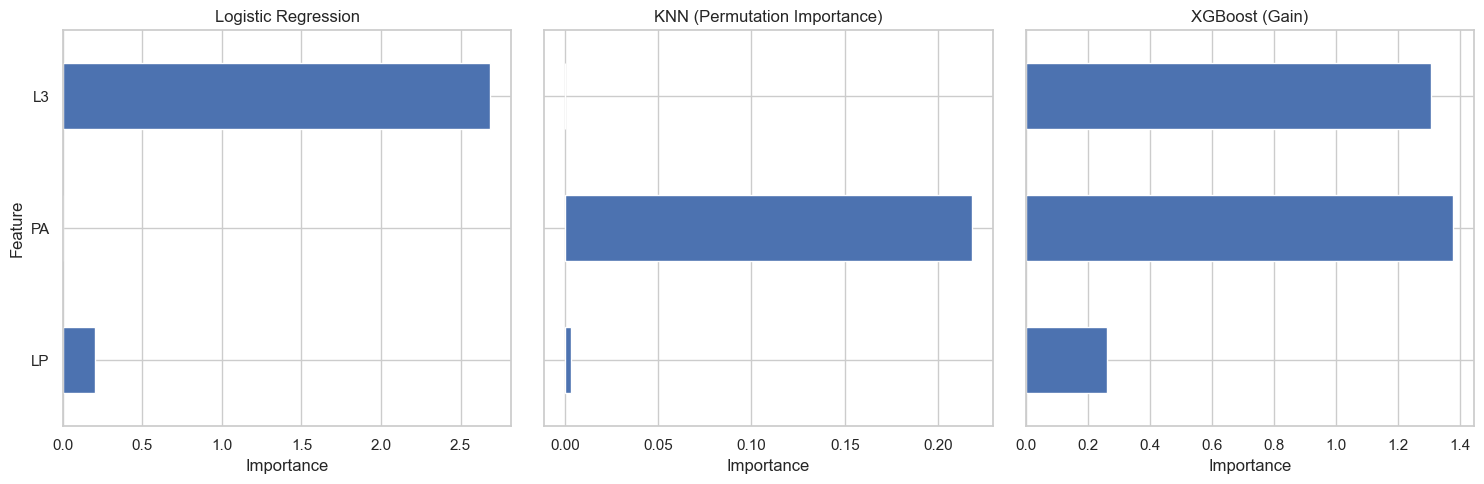

In [36]:
features = ['LP', 'PA', 'L3']

# Train and retrieve models
classifier_results, trained_models, X_test, y_test = train_classifiers_keepmodel(train_df2, test_df2, features)

# Retrieve correct models
lr_model = trained_models['Logistic Regression']
knn_model = trained_models['KNN']
xgb_model = trained_models['XGBoost']

# Compute importances
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=features)

perm_importance = permutation_importance(knn_model, X_test, y_test, n_repeats=30, random_state=42)
knn_importance = pd.Series(perm_importance.importances_mean, index=features)

xgb_importance_raw = xgb_model.get_booster().get_score(importance_type='gain')
xgb_feature_map = {f"f{i}": feat for i, feat in enumerate(features)}
xgb_importance = pd.Series({xgb_feature_map.get(k, k): v for k, v in xgb_importance_raw.items()})
xgb_importance = xgb_importance.reindex(features).fillna(0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Consistent feature order
lr_importance.reindex(features).plot.barh(ax=axes[0], title='Logistic Regression')
knn_importance.reindex(features).plot.barh(ax=axes[1], title='KNN (Permutation Importance)')
xgb_importance.reindex(features).plot.barh(ax=axes[2], title='XGBoost (Gain)')

for ax in axes:
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

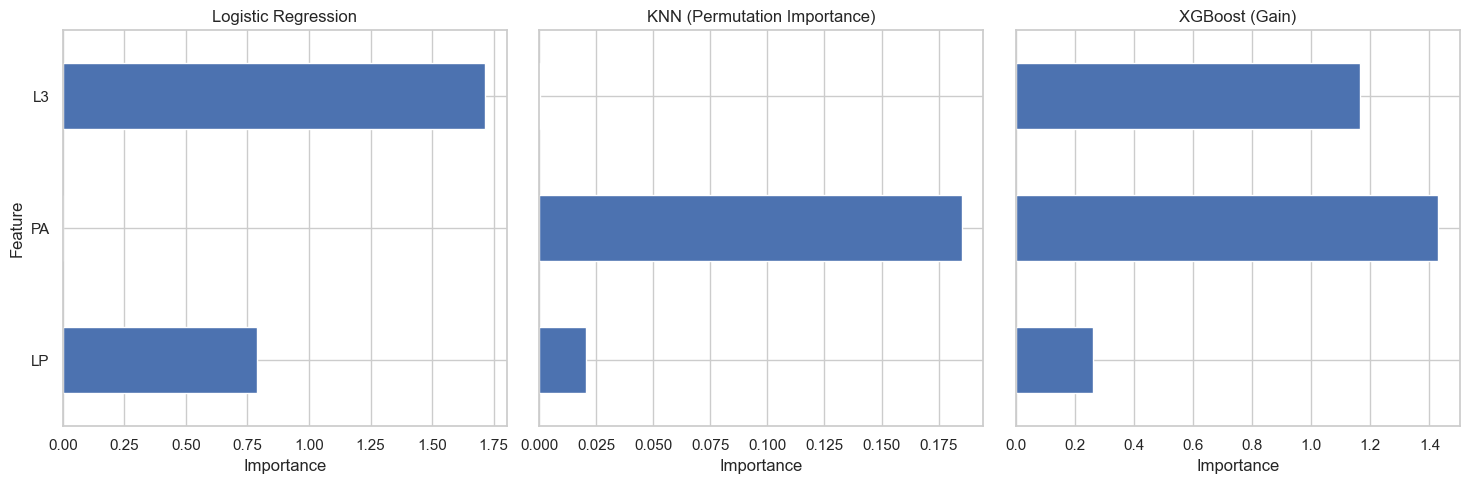

In [37]:
# Train and retrieve models
classifier_results, trained_models, X_test, y_test = train_classifiers_keepmodel(train_df3, test_df3, features)

# Retrieve correct models
lr_model = trained_models['Logistic Regression']
knn_model = trained_models['KNN']
xgb_model = trained_models['XGBoost']

# Compute importances
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=features)

perm_importance = permutation_importance(knn_model, X_test, y_test, n_repeats=30, random_state=42)
knn_importance = pd.Series(perm_importance.importances_mean, index=features)

xgb_importance_raw = xgb_model.get_booster().get_score(importance_type='gain')
xgb_feature_map = {f"f{i}": feat for i, feat in enumerate(features)}
xgb_importance = pd.Series({xgb_feature_map.get(k, k): v for k, v in xgb_importance_raw.items()})
xgb_importance = xgb_importance.reindex(features).fillna(0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Consistent feature order
lr_importance.reindex(features).plot.barh(ax=axes[0], title='Logistic Regression')
knn_importance.reindex(features).plot.barh(ax=axes[1], title='KNN (Permutation Importance)')
xgb_importance.reindex(features).plot.barh(ax=axes[2], title='XGBoost (Gain)')

for ax in axes:
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

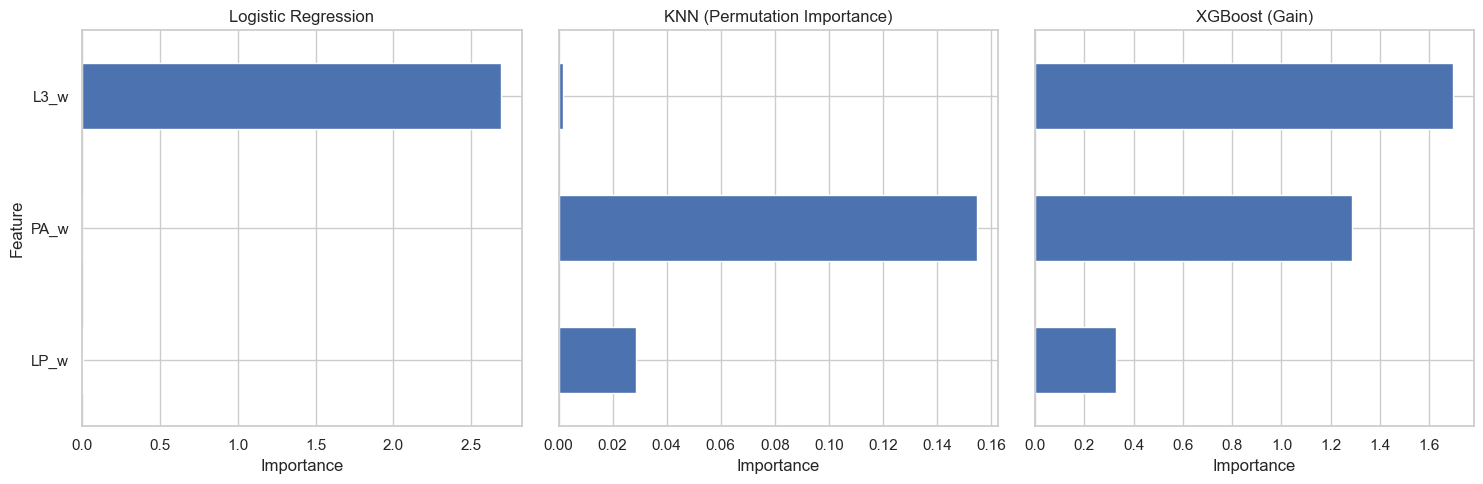

In [38]:
features = ['LP_w', 'PA_w', 'L3_w']

# Train and retrieve models
classifier_results, trained_models, X_test, y_test = train_classifiers_keepmodel(train_df2, test_df2, features)

# Retrieve correct models
lr_model = trained_models['Logistic Regression']
knn_model = trained_models['KNN']
xgb_model = trained_models['XGBoost']

# Compute importances
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=features)

perm_importance = permutation_importance(knn_model, X_test, y_test, n_repeats=30, random_state=42)
knn_importance = pd.Series(perm_importance.importances_mean, index=features)

xgb_importance_raw = xgb_model.get_booster().get_score(importance_type='gain')
xgb_feature_map = {f"f{i}": feat for i, feat in enumerate(features)}
xgb_importance = pd.Series({xgb_feature_map.get(k, k): v for k, v in xgb_importance_raw.items()})
xgb_importance = xgb_importance.reindex(features).fillna(0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Consistent feature order
lr_importance.reindex(features).plot.barh(ax=axes[0], title='Logistic Regression')
knn_importance.reindex(features).plot.barh(ax=axes[1], title='KNN (Permutation Importance)')
xgb_importance.reindex(features).plot.barh(ax=axes[2], title='XGBoost (Gain)')

for ax in axes:
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

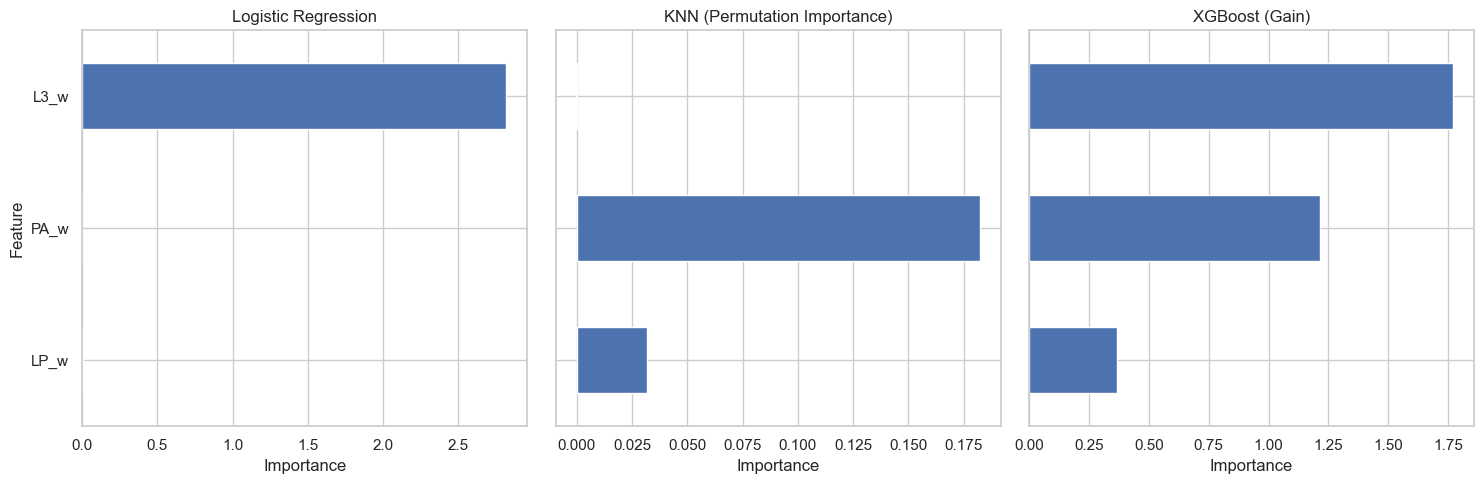

In [39]:
# Train and retrieve models
classifier_results, trained_models, X_test, y_test = train_classifiers_keepmodel(train_df3, test_df3, features)

# Retrieve correct models
lr_model = trained_models['Logistic Regression']
knn_model = trained_models['KNN']
xgb_model = trained_models['XGBoost']

# Compute importances
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=features)

perm_importance = permutation_importance(knn_model, X_test, y_test, n_repeats=30, random_state=42)
knn_importance = pd.Series(perm_importance.importances_mean, index=features)

xgb_importance_raw = xgb_model.get_booster().get_score(importance_type='gain')
xgb_feature_map = {f"f{i}": feat for i, feat in enumerate(features)}
xgb_importance = pd.Series({xgb_feature_map.get(k, k): v for k, v in xgb_importance_raw.items()})
xgb_importance = xgb_importance.reindex(features).fillna(0)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Consistent feature order
lr_importance.reindex(features).plot.barh(ax=axes[0], title='Logistic Regression')
knn_importance.reindex(features).plot.barh(ax=axes[1], title='KNN (Permutation Importance)')
xgb_importance.reindex(features).plot.barh(ax=axes[2], title='XGBoost (Gain)')

for ax in axes:
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()